Cuisine Labelling for 1.8 Million remaining recipes

In [2]:
from pathlib import Path
import time
import json
import ast
import re
import numpy as np
import pandas as pd
from datetime import datetime
from openai import OpenAI
import sys
import matplotlib.pyplot as plt
import time
print(sys.executable)

import pyarrow
print(pyarrow.__version__)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

ROOT = Path.cwd().parents[1]

TRIMMED_RECIPES_PATH = None
for p in ROOT.rglob("recipes_trimmed_keep_longest.parquet"):
    TRIMMED_RECIPES_PATH = p
    print("Found trimmed recipes:", p)

if TRIMMED_RECIPES_PATH is None:
    raise FileNotFoundError("Could not find recipes_trimmed_keep_longest.parquet")

EMBEDDINGS_PATH = ROOT / "Data" / "recipe_embeddings_fp16.npy"

OUT_DIR = ROOT / "scratch" / "EDA" / "semantic_cuisine_labeling"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Embeddings path exists:", EMBEDDINGS_PATH.exists())
print("Output dir:", OUT_DIR)

c:\Users\winni\anaconda3\envs\capstone\python.exe
24.0.0
Found trimmed recipes: c:\Users\winni\Documents\GitHub\Capstone\Capstone\Data\recipes_trimmed_keep_longest.parquet
Embeddings path exists: True
Output dir: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling


In [4]:
recipes_sample = pd.read_parquet(TRIMMED_RECIPES_PATH)

print(recipes_sample.shape)
print(recipes_sample.columns.tolist())
display(recipes_sample.head())

(1824097, 16)
['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'title_clean', 'directions_clean', 'ingredients_clean', 'semantic_text', 'ingredient_count', 'directions_length', 'duplicate_cluster_id', 'is_duplicate_candidate', 'keep_representative']


,Unnamed: 0,title,ingredients,directions,link,source,NER,title_clean,directions_clean,ingredients_clean,semantic_text,ingredient_count,directions_length,duplicate_cluster_id,is_duplicate_candidate,keep_representative
0,0,No-Bake Nut Cookies,"[1 c. firmly packed brown sugar, 1/2 c. evaporated milk, 1/2 tsp. vanilla, 1/2 c. broken nuts (pecans), 2 Tbsp. butter or margarine, 3 1/2 c. bite size shredded rice biscuits]","[""In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine."", ""Stir over medium heat until mixture bubbles all over top."", ""Boil and stir 5 minutes more. Take off heat."", ""Stir in vanilla and cereal; mix well."",...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""butter"", ""bite size shredded rice biscuits""]",no-bake nut cookies,"[""in a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine."", ""stir over medium heat until mixture bubbles all over top."", ""boil and stir 5 minutes more. take off heat."", ""stir in vanilla and cereal; mix well."",...","[firmly packed brown sugar, evaporated milk, vanilla, broken nuts, butter or margarine, bite size shredded rice biscuits]",no-bake nut cookies | bite size shredded rice biscuits broken nuts butter or margarine evaporated milk firmly packed brown sugar vanilla,6,357,NaN,False,True
1,1,Jewell Ball'S Chicken,"[1 small jar chipped beef, cut up, 4 boned chicken breasts, 1 can cream of mushroom soup, 1 carton sour cream]","[""Place chipped beef on bottom of baking dish."", ""Place chicken on top of beef."", ""Mix soup and cream together; pour over chicken. Bake, uncovered, at 275\u00b0 for 3 hours.""]",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom soup"", ""sour cream""]",jewell ball's chicken,"[""place chipped beef on bottom of baking dish."", ""place chicken on top of beef."", ""mix soup and cream together; pour over chicken. bake, uncovered, at 275\u00b0 for 3 hours.""]","[small chipped beef cut up, boned chicken breasts, cream of mushroom soup, carton sour cream]",jewell ball's chicken | boned chicken breasts carton sour cream cream of mushroom soup small chipped beef cut up,4,175,NaN,False,True
2,2,Creamy Corn,"[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. cream cheese, cubed, 1/3 c. butter, cubed, 1/2 tsp. garlic powder, 1/2 tsp. salt, 1/4 tsp. pepper]","[""In a slow cooker, combine all ingredients. Cover and cook on low for 4 hours or until heated through and cheese is melted. Stir well before serving. Yields 6 servings.""]",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""garlic powder"", ""salt"", ""pepper""]",creamy corn,"[""in a slow cooker, combine all ingredients. cover and cook on low for 4 hours or until heated through and cheese is melted. stir well before serving. yields 6 servings.""]","[frozen corn, cream cheese cubed, butter cubed, garlic powder, salt, pepper]",creamy corn | butter cubed cream cheese cubed frozen corn garlic powder pepper salt,6,171,0.0,True,True
3,3,Chicken Funny,"[1 large whole chicken, 2 (10 1/2 oz.) cans chicken gravy, 1 (10 1/2 oz.) can cream of mushroom soup, 1 (6 oz.) box Stove Top stuffing, 4 oz. shredded cheese]","[""Boil and debone chicken."", ""Put bite size pieces in average size square casserole dish."", ""Pour gravy and cream of mushroom soup over chicken; level."", ""Make stuffing according to instructions on box (do not make too moist)."", ""Put stuffing on ...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroom soup"", ""shredded cheese""]",chicken funny,"[""boil and debone chicken."", ""put bite size pieces in average size square casserole dish."", ""pour gravy and cream of mushroom soup over chicken; level."", ""make stuffing according to instructions on box (do not make too moist)."", ""put stuffing on

load needed columns only

In [5]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(TRIMMED_RECIPES_PATH)
available_cols = set(pf.schema.names)

candidate_cols = [
    "id",
    "recipe_id",
    "title",
    "ingredients",
    "NER",
    "ner",
    "link",
    "source",
]

load_cols = [c for c in candidate_cols if c in available_cols]

recipes = pd.read_parquet(TRIMMED_RECIPES_PATH, columns=load_cols)

print(recipes.shape)
print(recipes.columns.tolist())
display(recipes.head())

(1824097, 4)
['title', 'NER', 'link', 'source']


,title,NER,link,source
0,No-Bake Nut Cookies,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""butter"", ""bite size shredded rice biscuits""]",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered
1,Jewell Ball'S Chicken,"[""beef"", ""chicken breasts"", ""cream of mushroom soup"", ""sour cream""]",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered
2,Creamy Corn,"[""frozen corn"", ""cream cheese"", ""butter"", ""garlic powder"", ""salt"", ""pepper""]",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered
3,Chicken Funny,"[""chicken"", ""chicken gravy"", ""cream of mushroom soup"", ""shredded cheese""]",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered
5,Cheeseburger Potato Soup,"[""baking potatoes"", ""extra lean ground beef"", ""butter"", ""milk"", ""salt"", ""pepper"", ""Cheddar cheese"", ""bacon"", ""green onion"", ""sour cream""]",www.cookbooks.com/Recipe-Details.aspx?id=20115,Gathered


Normalize recipe ID and text fields

In [6]:
def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


recipe_id_col = first_existing_col(recipes, ["recipe_id", "id"])
title_col = first_existing_col(recipes, ["title"])
ingredients_col = first_existing_col(recipes, ["ingredients"])
ner_col = first_existing_col(recipes, ["NER", "ner"])
link_col = first_existing_col(recipes, ["link"])
source_col = first_existing_col(recipes, ["source"])

print("recipe_id_col:", recipe_id_col)
print("title_col:", title_col)
print("ingredients_col:", ingredients_col)
print("ner_col:", ner_col)
print("link_col:", link_col)
print("source_col:", source_col)

if recipe_id_col is None:
    recipes = recipes.reset_index().rename(columns={"index": "recipe_id"})
    recipe_id_col = "recipe_id"

recipes = recipes.rename(columns={recipe_id_col: "recipe_id"})

recipes["recipe_id"] = recipes["recipe_id"].astype(str)

recipe_id_col: None
title_col: title
ingredients_col: None
ner_col: NER
link_col: link
source_col: source


count cookbook recipes to omit

In [7]:
if link_col is not None:
    recipes["link_str"] = recipes[link_col].fillna("").astype(str).str.lower()

    cookbooks_mask = recipes["link_str"].str.contains("cookbooks.com", na=False)

    print("Total recipes:", len(recipes))
    print("cookbooks.com recipes:", cookbooks_mask.sum())
    print("non-cookbooks.com recipes:", (~cookbooks_mask).sum())
    print("cookbooks.com share:", cookbooks_mask.mean())

    display(recipes.loc[cookbooks_mask, ["recipe_id", title_col, link_col]].head(10))
else:
    recipes["link_str"] = ""
    cookbooks_mask = pd.Series(False, index=recipes.index)
    print("No link column found, so cookbooks.com count cannot be computed.")

Total recipes: 1824097
cookbooks.com recipes: 595077
non-cookbooks.com recipes: 1229020
cookbooks.com share: 0.3262310063554734


,recipe_id,title,link
0,0,No-Bake Nut Cookies,www.cookbooks.com/Recipe-Details.aspx?id=44874
1,1,Jewell Ball'S Chicken,www.cookbooks.com/Recipe-Details.aspx?id=699419
2,2,Creamy Corn,www.cookbooks.com/Recipe-Details.aspx?id=10570
3,3,Chicken Funny,www.cookbooks.com/Recipe-Details.aspx?id=897570
4,5,Cheeseburger Potato Soup,www.cookbooks.com/Recipe-Details.aspx?id=20115
5,7,Scalloped Corn,www.cookbooks.com/Recipe-Details.aspx?id=876969
6,8,Nolan'S Pepper Steak,www.cookbooks.com/Recipe-Details.aspx?id=375254
7,10,Double Cherry Delight,www.cookbooks.com/Recipe-Details.aspx?id=703381
8,11,Buckeye Candy,www.cookbooks.com/Recipe-Details.aspx?id=886785
9,12,Quick Barbecue Wings,www.cookbooks.com/Recipe-Details.aspx?id=768311


exclude cookbooks.com

In [8]:
recipes_working = recipes.loc[~cookbooks_mask].copy()

print("Working recipe count after excluding cookbooks.com:", len(recipes_working))

Working recipe count after excluding cookbooks.com: 1229020


Cuisine labels

In [4]:
CUISINE_TAXONOMY = [
    # North America / Western
    {"parent": "Western", "cuisine": "American", "aliases": ["American food", "United States cuisine", "classic American recipes", "burgers casseroles sandwiches barbecue"]},
    {"parent": "Western", "cuisine": "Southern US", "aliases": ["Southern food", "soul food", "Cajun food", "Creole food", "Louisiana cooking", "gumbo jambalaya biscuits grits"]},
    {"parent": "Western", "cuisine": "Canadian", "aliases": ["Canadian food", "poutine maple Canadian recipes"]},
    {"parent": "Western", "cuisine": "British / Irish", "aliases": ["British food", "Irish food", "English recipes", "pub food shepherd pie scones"]},
    {"parent": "Western", "cuisine": "Australian / New Zealand", "aliases": ["Australian food", "New Zealand food", "ANZAC pavlova meat pies"]},

    # Europe
    {"parent": "European", "cuisine": "Italian", "aliases": ["Italian food", "pasta pizza risotto parmesan basil tomato sauce"]},
    {"parent": "European", "cuisine": "French", "aliases": ["French food", "French cuisine", "butter wine cream herbs de provence baguette"]},
    {"parent": "European", "cuisine": "Spanish", "aliases": ["Spanish food", "paella tapas saffron chorizo paprika"]},
    {"parent": "European", "cuisine": "Greek", "aliases": ["Greek food", "feta olives oregano lemon lamb tzatziki spanakopita"]},
    {"parent": "European", "cuisine": "German / Central European", "aliases": ["German food", "Austrian food", "Central European cuisine", "sausages sauerkraut schnitzel dumplings"]},
    {"parent": "European", "cuisine": "Eastern European", "aliases": ["Polish Ukrainian Russian Eastern European food", "pierogi borscht cabbage dill sour cream"]},
    {"parent": "European", "cuisine": "Nordic / Scandinavian", "aliases": ["Nordic food", "Scandinavian cuisine", "Swedish Norwegian Danish recipes", "salmon dill rye lingonberry"]},

    # Latin America and Caribbean
    {"parent": "Latin American", "cuisine": "Mexican", "aliases": ["Mexican food", "tacos enchiladas tortillas salsa cilantro jalapeno beans"]},
    {"parent": "Latin American", "cuisine": "Tex-Mex", "aliases": ["Tex-Mex food", "chili con carne nachos queso fajitas taco seasoning"]},
    {"parent": "Latin American", "cuisine": "Central American", "aliases": ["Central American food", "Salvadoran Guatemalan Honduran pupusas plantains beans corn"]},
    {"parent": "Latin American", "cuisine": "Brazilian", "aliases": ["Brazilian food", "feijoada farofa churrasco cassava pão de queijo"]},
    {"parent": "Latin American", "cuisine": "South American", "aliases": ["Peruvian Colombian Argentinian Chilean South American food", "aji quinoa ceviche empanadas chimichurri"]},
    {"parent": "Caribbean", "cuisine": "Caribbean", "aliases": ["Caribbean food", "Jamaican Cuban Puerto Rican Haitian food", "jerk plantains allspice coconut rice beans"]},

    # East Asia
    {"parent": "East Asian", "cuisine": "Chinese", "aliases": ["Chinese food", "soy sauce ginger garlic scallion stir fry hoisin oyster sauce"]},
    {"parent": "East Asian", "cuisine": "Japanese", "aliases": ["Japanese food", "miso mirin dashi sushi ramen soy sauce nori"]},
    {"parent": "East Asian", "cuisine": "Korean", "aliases": ["Korean food", "kimchi gochujang sesame garlic scallion bulgogi"]},
    {"parent": "East Asian", "cuisine": "Taiwanese", "aliases": ["Taiwanese food", "bubble tea oyster omelette lu rou fan five spice"]},

    # Southeast Asia
    {"parent": "Southeast Asian", "cuisine": "Thai", "aliases": ["Thai food", "fish sauce lemongrass galangal coconut milk curry paste basil lime"]},
    {"parent": "Southeast Asian", "cuisine": "Vietnamese", "aliases": ["Vietnamese food", "fish sauce rice noodles pho banh mi mint cilantro lime"]},
    {"parent": "Southeast Asian", "cuisine": "Filipino", "aliases": ["Filipino food", "adobo lumpia pancit vinegar soy sauce calamansi"]},
    {"parent": "Southeast Asian", "cuisine": "Indonesian / Malaysian", "aliases": ["Indonesian Malaysian food", "satay sambal rendang coconut rice kecap manis"]},
    {"parent": "Southeast Asian", "cuisine": "Southeast Asian General", "aliases": ["Southeast Asian food", "fish sauce coconut milk lemongrass rice noodles tamarind"]},

    # South Asia
    {"parent": "South Asian", "cuisine": "Indian", "aliases": ["Indian food", "curry garam masala turmeric cumin coriander dal paneer naan"]},
    {"parent": "South Asian", "cuisine": "Pakistani", "aliases": ["Pakistani food", "biryani kebab nihari garam masala cumin coriander"]},
    {"parent": "South Asian", "cuisine": "Bangladeshi", "aliases": ["Bangladeshi food", "fish curry mustard oil rice lentils turmeric"]},
    {"parent": "South Asian", "cuisine": "Sri Lankan", "aliases": ["Sri Lankan food", "coconut curry curry leaves rice hoppers"]},
    {"parent": "South Asian", "cuisine": "South Asian General", "aliases": ["South Asian food", "curry lentils rice cumin turmeric garam masala"]},

    # Middle East / Central Asia
    {"parent": "Middle Eastern", "cuisine": "Levantine", "aliases": ["Lebanese Syrian Palestinian Israeli Jordanian food", "hummus tahini zaatar pita falafel sumac"]},
    {"parent": "Middle Eastern", "cuisine": "Turkish", "aliases": ["Turkish food", "kebab yogurt eggplant sumac pide bulgur"]},
    {"parent": "Middle Eastern", "cuisine": "Persian / Iranian", "aliases": ["Persian Iranian food", "saffron rice pomegranate herbs kebab tahdig"]},
    {"parent": "Middle Eastern", "cuisine": "Middle Eastern General", "aliases": ["Middle Eastern food", "tahini chickpeas pita lamb yogurt cumin coriander"]},
    {"parent": "Central Asian", "cuisine": "Central Asian", "aliases": ["Central Asian food", "Uzbek Kazakh Afghan food", "pilaf plov lamb rice cumin"]},

    # Africa
    {"parent": "North African", "cuisine": "Moroccan", "aliases": ["Moroccan food", "tagine couscous harissa preserved lemon ras el hanout"]},
    {"parent": "North African", "cuisine": "North African General", "aliases": ["North African food", "Egyptian Tunisian Algerian food", "couscous harissa cumin lamb"]},
    {"parent": "African", "cuisine": "Ethiopian / Eritrean", "aliases": ["Ethiopian Eritrean food", "injera berbere lentils wat teff"]},
    {"parent": "African", "cuisine": "West African", "aliases": ["West African food", "Nigerian Ghanaian Senegalese food", "jollof rice peanuts plantains cassava"]},
    {"parent": "African", "cuisine": "East African", "aliases": ["East African food", "Kenyan Tanzanian Ugandan food", "chapati beans coconut curry"]},
    {"parent": "African", "cuisine": "African General", "aliases": ["African food", "cassava plantain peanuts millet sorghum stews"]},

    # Other / broad
    {"parent": "Global", "cuisine": "Mediterranean General", "aliases": ["Mediterranean food", "olive oil lemon herbs vegetables fish feta olives"]},
    {"parent": "Global", "cuisine": "Fusion", "aliases": ["fusion food", "mixed cuisine", "global fusion recipes"]},
    {"parent": "Global", "cuisine": "Unclear / General", "aliases": ["generic recipe", "general food", "no clear cuisine"]},
]

build text for semantic matching

In [10]:
def parse_maybe_list(value):
    if isinstance(value, list):
        return " ".join(map(str, value))

    if pd.isna(value):
        return ""

    text = str(value)

    # Try parsing list-like strings, common in RecipeNLG columns
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                return " ".join(map(str, parsed))
        except Exception:
            pass

    return text


def build_recipe_semantic_text(row):
    parts = []

    if title_col is not None:
        parts.append(f"Title: {row.get(title_col, '')}")

    if ingredients_col is not None:
        parts.append(f"Ingredients: {parse_maybe_list(row.get(ingredients_col, ''))}")

    if ner_col is not None:
        parts.append(f"Ingredient names: {parse_maybe_list(row.get(ner_col, ''))}")

    return " | ".join(parts)


recipes_working["semantic_text"] = recipes_working.apply(build_recipe_semantic_text, axis=1)

display(recipes_working[["recipe_id", title_col, "semantic_text"]].head(10))

,recipe_id,title,semantic_text
595077,896341,Deconstructed Screwdriver (The Raw Egg),Title: Deconstructed Screwdriver (The Raw Egg) | Ingredient names: orange juice jiggers vodka
595078,896342,Kettle Corn,Title: Kettle Corn | Ingredient names: vegetable oil white sugar popcorn kernels
595079,896343,Pop'S Fabulous Ajvar,Title: Pop'S Fabulous Ajvar | Ingredient names: eggplants green bell peppers red bell peppers cooking spray garlic salt white vinegar corn oil
595080,896344,Chipotle-Mango Guacamole,Title: Chipotle-Mango Guacamole | Ingredient names: avocados tomatoes mango cilantro red onion peppers pepper sour cream lime juice garlic cayenne pepper ground cumin black pepper
595081,896345,Basic Homemade Ricotta Cheese,Title: Basic Homemade Ricotta Cheese | Ingredient names: milk heavy whipping cream white vinegar salt
595082,896346,Asian Salmon Patties,Title: Asian Salmon Patties | Ingredient names: sesame oil salmon eggs bread crumbs green bell pepper green onions fresh ginger soy sauce sesame seeds
595083,896347,Navajo Tacos,Title: Navajo Tacos | Ingredient names: Chili Beans pinto beans water frozen chili ground cumin oregano garlic onion powder salt Fry Bread flour baking powder salt hot water lard Toppings Cheddar cheese tomatoes onions
595084,896348,One-Pot White Chicken Chili,Title: One-Pot White Chicken Chili | Ingredient names: olive oil skinless garlic chives oregano thyme basil salt bay leaf great Northern beans water tomatoes salsa sour cream
595085,896349,Grandmom Marino'S Easter Meat Pie,Title: Grandmom Marino'S Easter Meat Pie | Ingredient names: ham salami ricotta cheese egg parsley salt
595086,896350,Basic Chinese Stir Fry Vegetables,Title: Basic Chinese Stir Fry Vegetables | Ingredient names: brown rice water safflower oil leeks garlic fresh ginger root zucchini carrots yellow squash salt


prototype cuisine labelling

In [11]:
prototype_rows = []

for item in CUISINE_TAXONOMY:
    parent = item["parent"]
    cuisine = item["cuisine"]
    aliases = item["aliases"]

    for alias in aliases:
        prototype_rows.append({
            "semantic_parent_cuisine": parent,
            "semantic_cuisine": cuisine,
            "prototype_text": alias,
        })

prototype_df = pd.DataFrame(prototype_rows)

print(prototype_df.shape)
display(prototype_df.head(20))

(113, 3)


,semantic_parent_cuisine,semantic_cuisine,prototype_text
0,Western,American,American food
1,Western,American,United States cuisine
2,Western,American,classic American recipes
3,Western,American,burgers casseroles sandwiches barbecue
4,Western,Southern US,Southern food
5,Western,Southern US,soul food
6,Western,Southern US,Cajun food
7,Western,Southern US,Creole food
8,Western,Southern US,Louisiana cooking
9,Western,Southern US,gumbo jambalaya biscuits grits


load embedding model

In [12]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

c:\Users\winni\anaconda3\envs\capstone\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3672.27it/s]


embed cuisine prototype

In [13]:
prototype_embeddings = embedder.encode(
    prototype_df["prototype_text"].tolist(),
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True,
).astype("float32")

print(prototype_embeddings.shape)

Batches: 100%|██████████| 2/2 [00:00<00:00,  5.12it/s]

(113, 384)


load existing recipe embeddings if aligned

In [14]:
use_existing_embeddings = False
recipe_embeddings = None

if EMBEDDINGS_PATH.exists():
    recipe_embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")
    print("Recipe embeddings shape:", recipe_embeddings.shape)
    print("Recipes shape:", recipes.shape)

    if recipe_embeddings.shape[0] == len(recipes):
        use_existing_embeddings = True
        print("Existing embeddings align with full recipes dataframe.")
    else:
        print("Existing embeddings do NOT align with loaded recipes dataframe. Do not use directly.")

print("use_existing_embeddings:", use_existing_embeddings)

Recipe embeddings shape: (2231142, 384)
Recipes shape: (1824097, 6)
Existing embeddings do NOT align with loaded recipes dataframe. Do not use directly.
use_existing_embeddings: False


test 10,000

In [15]:
N_TEST = 10_000

test_recipes = recipes_working.head(N_TEST).copy()
test_positions = test_recipes.index.to_numpy()

print(test_recipes.shape)
display(test_recipes[["recipe_id", title_col, "semantic_text"]].head())

(10000, 7)


,recipe_id,title,semantic_text
595077,896341,Deconstructed Screwdriver (The Raw Egg),Title: Deconstructed Screwdriver (The Raw Egg) | Ingredient names: orange juice jiggers vodka
595078,896342,Kettle Corn,Title: Kettle Corn | Ingredient names: vegetable oil white sugar popcorn kernels
595079,896343,Pop'S Fabulous Ajvar,Title: Pop'S Fabulous Ajvar | Ingredient names: eggplants green bell peppers red bell peppers cooking spray garlic salt white vinegar corn oil
595080,896344,Chipotle-Mango Guacamole,Title: Chipotle-Mango Guacamole | Ingredient names: avocados tomatoes mango cilantro red onion peppers pepper sour cream lime juice garlic cayenne pepper ground cumin black pepper
595081,896345,Basic Homemade Ricotta Cheese,Title: Basic Homemade Ricotta Cheese | Ingredient names: milk heavy whipping cream white vinegar salt


get embeddings for test set

In [16]:
start = time.perf_counter()

if use_existing_embeddings:
    test_embeddings = np.asarray(recipe_embeddings[test_positions], dtype="float32")

    # Normalize in case stored embeddings are not normalized
    norms = np.linalg.norm(test_embeddings, axis=1, keepdims=True)
    test_embeddings = test_embeddings / np.clip(norms, 1e-12, None)

else:
    test_embeddings = embedder.encode(
        test_recipes["semantic_text"].tolist(),
        batch_size=256,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).astype("float32")

elapsed = time.perf_counter() - start

print("Test embeddings shape:", test_embeddings.shape)
print(f"Embedding load/creation time: {elapsed:.2f} seconds")

Batches: 100%|██████████| 40/40 [00:22<00:00,  1.80it/s]

Test embeddings shape: (10000, 384)
Embedding load/creation time: 22.23 seconds


assign semantic suisine labels

In [17]:
def assign_semantic_cuisine(recipe_embs, prototype_embs, prototype_df):
    # cosine similarity because embeddings are normalized
    sims = recipe_embs @ prototype_embs.T

    top_proto_idx = sims.argmax(axis=1)
    top_score = sims[np.arange(len(sims)), top_proto_idx]

    # second-best prototype score for margin
    part = np.partition(sims, -2, axis=1)
    second_score = part[:, -2]
    margin = top_score - second_score

    result = prototype_df.iloc[top_proto_idx].reset_index(drop=True).copy()
    result["semantic_cuisine_score"] = top_score
    result["semantic_cuisine_margin"] = margin

    return result


start = time.perf_counter()

test_labels = assign_semantic_cuisine(
    test_embeddings,
    prototype_embeddings,
    prototype_df
)

elapsed = time.perf_counter() - start

print(f"Semantic labeling time for {len(test_labels):,} recipes: {elapsed:.2f} seconds")

test_labeled = pd.concat(
    [
        test_recipes.reset_index(drop=True),
        test_labels.reset_index(drop=True),
    ],
    axis=1,
)

display(
    test_labeled[
        [
            "recipe_id",
            title_col,
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "prototype_text",
        ]
    ].head(30)
)

Semantic labeling time for 10,000 recipes: 0.04 seconds


,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,prototype_text
0,896341,Deconstructed Screwdriver (The Raw Egg),East Asian,Taiwanese,0.398102,0.020789,bubble tea oyster omelette lu rou fan five spice
1,896342,Kettle Corn,Latin American,Central American,0.445732,0.039480,Salvadoran Guatemalan Honduran pupusas plantains beans corn
2,896343,Pop'S Fabulous Ajvar,East Asian,Taiwanese,0.465672,0.010646,bubble tea oyster omelette lu rou fan five spice
3,896344,Chipotle-Mango Guacamole,Southeast Asian,Thai,0.457709,0.011583,fish sauce lemongrass galangal coconut milk curry paste basil lime
4,896345,Basic Homemade Ricotta Cheese,Southeast Asian,Filipino,0.474099,0.073372,adobo lumpia pancit vinegar soy sauce calamansi
5,896346,Asian Salmon Patties,Southeast Asian,Southeast Asian General,0.559710,0.022272,Southeast Asian food
6,896347,Navajo Tacos,Latin American,Mexican,0.581307,0.061942,tacos enchiladas tortillas salsa cilantro jalapeno beans
7,896348,One-Pot White Chicken Chili,Global,Mediterranean General,0.492215,0.017496,olive oil lemon herbs vegetables fish feta olives
8,896349,Grandmom Marino'S Easter Meat Pie,European,Italian,0.516733,0.040305,Italian food
9,896350,Basic Chinese Stir Fry Vegetables,East Asian,Chinese,0.543948,0.022899,Chinese food


add confidence buckets

In [18]:
def semantic_confidence_bucket(score, margin):
    if score >= 0.55 and margin >= 0.05:
        return "high"
    elif score >= 0.45 and margin >= 0.03:
        return "medium"
    elif score >= 0.35:
        return "low"
    else:
        return "very_low"


test_labeled["semantic_cuisine_confidence"] = [
    semantic_confidence_bucket(s, m)
    for s, m in zip(
        test_labeled["semantic_cuisine_score"],
        test_labeled["semantic_cuisine_margin"],
    )
]

test_labeled["semantic_cuisine_method"] = "semantic_prototype_similarity"

display(
    test_labeled[
        [
            "recipe_id",
            title_col,
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "semantic_cuisine_confidence",
            "prototype_text",
        ]
    ].head(50)
)

,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence,prototype_text
0,896341,Deconstructed Screwdriver (The Raw Egg),East Asian,Taiwanese,0.398102,0.020789,low,bubble tea oyster omelette lu rou fan five spice
1,896342,Kettle Corn,Latin American,Central American,0.445732,0.039480,low,Salvadoran Guatemalan Honduran pupusas plantains beans corn
2,896343,Pop'S Fabulous Ajvar,East Asian,Taiwanese,0.465672,0.010646,low,bubble tea oyster omelette lu rou fan five spice
3,896344,Chipotle-Mango Guacamole,Southeast Asian,Thai,0.457709,0.011583,low,fish sauce lemongrass galangal coconut milk curry paste basil lime
4,896345,Basic Homemade Ricotta Cheese,Southeast Asian,Filipino,0.474099,0.073372,medium,adobo lumpia pancit vinegar soy sauce calamansi
5,896346,Asian Salmon Patties,Southeast Asian,Southeast Asian General,0.559710,0.022272,low,Southeast Asian food
6,896347,Navajo Tacos,Latin American,Mexican,0.581307,0.061942,high,tacos enchiladas tortillas salsa cilantro jalapeno beans
7,896348,One-Pot White Chicken Chili,Global,Mediterranean General,0.492215,0.017496,low,olive oil lemon herbs vegetables fish feta olives
8,896349,Grandmom Marino'S Easter Meat Pie,European,Italian,0.516733,0.040305,medium,Italian food
9,896350,Basic Chinese Stir Fry Vegetables,East Asian,Chinese,0.543948,0.022899,low,Chinese food


summarize results

In [19]:
display(
    test_labeled["semantic_cuisine"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "semantic_cuisine", "semantic_cuisine": "n_recipes"})
    .head(30)
)

display(
    test_labeled["semantic_cuisine_confidence"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "confidence", "semantic_cuisine_confidence": "n_recipes"})
)

recipes_per_second = len(test_labeled) / elapsed if elapsed > 0 else np.nan
estimated_full_seconds = len(recipes_working) / recipes_per_second

print(f"Labeling speed: {recipes_per_second:,.0f} recipes/sec")
print(f"Estimated full labeling time: {estimated_full_seconds/60:.1f} minutes")

,n_recipes,count
0,Turkish,916
1,Southern US,909
2,Thai,715
3,American,661
4,Italian,586
5,Korean,566
6,Chinese,539
7,Southeast Asian General,511
8,British / Irish,478
9,Mexican,429


,n_recipes,count
0,low,6968
1,medium,2310
2,high,616
3,very_low,106


Labeling speed: 241,311 recipes/sec
Estimated full labeling time: 0.1 minutes


save test output

In [20]:
test_out_path = OUT_DIR / "semantic_cuisine_labeled_test_10000.parquet"
test_labeled.to_parquet(test_out_path, index=False)

print("Wrote:", test_out_path)

Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_cuisine_labeled_test_10000.parquet


Full run (If results good)

In [21]:
FULL_OUT_PATH = OUT_DIR / "recipes_trimmed_semantic_cuisine_labeled_no_cookbooks.parquet"

CHUNK_SIZE = 50_000

all_labeled_chunks = []

start_full = time.perf_counter()

n = len(recipes_working)

for start_idx in range(0, n, CHUNK_SIZE):
    end_idx = min(start_idx + CHUNK_SIZE, n)

    chunk = recipes_working.iloc[start_idx:end_idx].copy()
    positions = chunk.index.to_numpy()

    print(f"Processing rows {start_idx:,} to {end_idx:,} of {n:,}")

    if use_existing_embeddings:
        chunk_embs = np.asarray(recipe_embeddings[positions], dtype="float32")
        norms = np.linalg.norm(chunk_embs, axis=1, keepdims=True)
        chunk_embs = chunk_embs / np.clip(norms, 1e-12, None)
    else:
        chunk_embs = embedder.encode(
            chunk["semantic_text"].tolist(),
            batch_size=256,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype("float32")

    chunk_labels = assign_semantic_cuisine(
        chunk_embs,
        prototype_embeddings,
        prototype_df
    )

    chunk_labeled = pd.concat(
        [
            chunk.reset_index(drop=True),
            chunk_labels.reset_index(drop=True),
        ],
        axis=1,
    )

    chunk_labeled["semantic_cuisine_confidence"] = [
        semantic_confidence_bucket(s, m)
        for s, m in zip(
            chunk_labeled["semantic_cuisine_score"],
            chunk_labeled["semantic_cuisine_margin"],
        )
    ]

    chunk_labeled["semantic_cuisine_method"] = "semantic_prototype_similarity"

    all_labeled_chunks.append(chunk_labeled)

full_labeled = pd.concat(all_labeled_chunks, ignore_index=True)

elapsed_full = time.perf_counter() - start_full

print(f"Full labeling complete: {len(full_labeled):,} rows")
print(f"Elapsed time: {elapsed_full/60:.1f} minutes")

full_labeled.to_parquet(FULL_OUT_PATH, index=False)

print("Wrote:", FULL_OUT_PATH)

Processing rows 0 to 50,000 of 1,229,020
Processing rows 50,000 to 100,000 of 1,229,020
Processing rows 100,000 to 150,000 of 1,229,020
Processing rows 150,000 to 200,000 of 1,229,020
Processing rows 200,000 to 250,000 of 1,229,020
Processing rows 250,000 to 300,000 of 1,229,020
Processing rows 300,000 to 350,000 of 1,229,020
Processing rows 350,000 to 400,000 of 1,229,020
Processing rows 400,000 to 450,000 of 1,229,020
Processing rows 450,000 to 500,000 of 1,229,020
Processing rows 500,000 to 550,000 of 1,229,020
Processing rows 550,000 to 600,000 of 1,229,020
Processing rows 600,000 to 650,000 of 1,229,020
Processing rows 650,000 to 700,000 of 1,229,020
Processing rows 700,000 to 750,000 of 1,229,020
Processing rows 750,000 to 800,000 of 1,229,020
Processing rows 800,000 to 850,000 of 1,229,020
Processing rows 850,000 to 900,000 of 1,229,020
Processing rows 900,000 to 950,000 of 1,229,020
Processing rows 950,000 to 1,000,000 of 1,229,020
Processing rows 1,000,000 to 1,050,000 of 1,22

Confidence and Cuisine Categories

In [22]:
# Use full_labeled if it exists, otherwise load from disk

if "full_labeled" in globals() and full_labeled is not None:
    stats_df = full_labeled.copy()
else:
    stats_df = pd.read_parquet(FULL_OUT_PATH)

print("Rows in labeled dataset:", len(stats_df))
print(stats_df.columns.tolist())
display(stats_df.head())

Rows in labeled dataset: 1229020
['recipe_id', 'title', 'NER', 'link', 'source', 'link_str', 'semantic_text', 'semantic_parent_cuisine', 'semantic_cuisine', 'prototype_text', 'semantic_cuisine_score', 'semantic_cuisine_margin', 'semantic_cuisine_confidence', 'semantic_cuisine_method']


,recipe_id,title,NER,link,source,link_str,semantic_text,semantic_parent_cuisine,semantic_cuisine,prototype_text,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence,semantic_cuisine_method
0,896341,Deconstructed Screwdriver (The Raw Egg),"[""orange juice"", ""jiggers vodka""]",www.allrecipes.com/recipe/241895/deconstructed-screwdriver-the-raw-egg/,Gathered,www.allrecipes.com/recipe/241895/deconstructed-screwdriver-the-raw-egg/,Title: Deconstructed Screwdriver (The Raw Egg) | Ingredient names: orange juice jiggers vodka,East Asian,Taiwanese,bubble tea oyster omelette lu rou fan five spice,0.398102,0.020789,low,semantic_prototype_similarity
1,896342,Kettle Corn,"[""vegetable oil"", ""white sugar"", ""popcorn kernels""]",www.allrecipes.com/recipe/20808/kettle-corn/,Gathered,www.allrecipes.com/recipe/20808/kettle-corn/,Title: Kettle Corn | Ingredient names: vegetable oil white sugar popcorn kernels,Latin American,Central American,Salvadoran Guatemalan Honduran pupusas plantains beans corn,0.445732,0.039480,low,semantic_prototype_similarity
2,896343,Pop'S Fabulous Ajvar,"[""eggplants"", ""green bell peppers"", ""red bell peppers"", ""cooking spray"", ""garlic"", ""salt"", ""white vinegar"", ""corn oil""]",www.allrecipes.com/recipe/238733/pops-fabulous-ajvar/,Gathered,www.allrecipes.com/recipe/238733/pops-fabulous-ajvar/,Title: Pop'S Fabulous Ajvar | Ingredient names: eggplants green bell peppers red bell peppers cooking spray garlic salt white vinegar corn oil,East Asian,Taiwanese,bubble tea oyster omelette lu rou fan five spice,0.465672,0.010646,low,semantic_prototype_similarity
3,896344,Chipotle-Mango Guacamole,"[""avocados"", ""tomatoes"", ""mango"", ""cilantro"", ""red onion"", ""peppers"", ""pepper"", ""sour cream"", ""lime juice"", ""garlic"", ""cayenne pepper"", ""ground cumin"", ""black pepper""]",www.allrecipes.com/recipe/241254/chipotle-mango-guacamole/,Gathered,www.allrecipes.com/recipe/241254/chipotle-mango-guacamole/,Title: Chipotle-Mango Guacamole | Ingredient names: avocados tomatoes mango cilantro red onion peppers pepper sour cream lime juice garlic cayenne pepper ground cumin black pepper,Southeast Asian,Thai,fish sauce lemongrass galangal coconut milk curry paste basil lime,0.457709,0.011584,low,semantic_prototype_similarity
4,896345,Basic Homemade Ricotta Cheese,"[""milk"", ""heavy whipping cream"", ""white vinegar"", ""salt""]",www.allrecipes.com/recipe/261696/basic-homemade-ricotta-cheese/,Gathered,www.allrecipes.com/recipe/261696/basic-homemade-ricotta-cheese/,Title: Basic Homemade Ricotta Cheese | Ingredient names: milk heavy whipping cream white vinegar salt,Southeast Asian,Filipino,adobo lumpia pancit vinegar soy sauce calamansi,0.474099,0.073372,medium,semantic_prototype_similarity


stats by specific cuisine

In [23]:
semantic_cuisine_stats = (
    stats_df
    .groupby(["semantic_parent_cuisine", "semantic_cuisine"], dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_score=("semantic_cuisine_score", "mean"),
        median_score=("semantic_cuisine_score", "median"),
        avg_margin=("semantic_cuisine_margin", "mean"),
        median_margin=("semantic_cuisine_margin", "median"),
        high_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "high").sum()),
        medium_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "medium").sum()),
        low_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "low").sum()),
        very_low_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "very_low").sum()),
    )
    .reset_index()
)

semantic_cuisine_stats["share_of_dataset"] = (
    semantic_cuisine_stats["n_recipes"] / len(stats_df)
)

semantic_cuisine_stats = semantic_cuisine_stats.sort_values(
    "n_recipes",
    ascending=False
)

display(semantic_cuisine_stats.head(50))

,semantic_parent_cuisine,semantic_cuisine,n_recipes,avg_score,median_score,avg_margin,median_margin,high_confidence_count,medium_confidence_count,low_confidence_count,very_low_confidence_count,share_of_dataset
28,Middle Eastern,Turkish,108519,0.450862,0.446482,0.034974,0.027094,2983,30077,74230,1229,0.088297
45,Western,Southern US,98545,0.444491,0.438076,0.040886,0.031124,3418,24720,68839,1568,0.080182
39,Southeast Asian,Thai,93620,0.486458,0.484842,0.027959,0.022060,4578,24887,63552,603,0.076175
14,European,Italian,79471,0.525040,0.522938,0.042831,0.033212,16513,25007,37931,20,0.064662
41,Western,American,74474,0.457881,0.455585,0.033845,0.022333,4038,20523,48338,1575,0.060596
6,East Asian,Chinese,73420,0.507217,0.503370,0.032144,0.023371,8051,20548,44789,32,0.059739
8,East Asian,Korean,72732,0.491546,0.488368,0.026310,0.019690,4212,17878,50403,239,0.059179
19,Global,Unclear / General,57363,0.410559,0.410293,0.020741,0.016377,16,3168,51905,2274,0.046674
38,Southeast Asian,Southeast Asian General,57138,0.484662,0.481852,0.020965,0.015905,1255,11313,44380,190,0.046491
22,Latin American,Mexican,51716,0.530714,0.528525,0.054234,0.045510,14623,17946,19138,9,0.042079


stats by parent cuisine

In [24]:
parent_cuisine_stats = (
    stats_df
    .groupby("semantic_parent_cuisine", dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_score=("semantic_cuisine_score", "mean"),
        median_score=("semantic_cuisine_score", "median"),
        avg_margin=("semantic_cuisine_margin", "mean"),
        median_margin=("semantic_cuisine_margin", "median"),
        high_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "high").sum()),
        medium_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "medium").sum()),
        low_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "low").sum()),
        very_low_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "very_low").sum()),
    )
    .reset_index()
)

parent_cuisine_stats["share_of_dataset"] = (
    parent_cuisine_stats["n_recipes"] / len(stats_df)
)

parent_cuisine_stats = parent_cuisine_stats.sort_values(
    "n_recipes",
    ascending=False
)

display(parent_cuisine_stats)

,semantic_parent_cuisine,n_recipes,avg_score,median_score,avg_margin,median_margin,high_confidence_count,medium_confidence_count,low_confidence_count,very_low_confidence_count,share_of_dataset
11,Western,238984,0.450848,0.445289,0.037780,0.026733,10034,63569,161390,3991,0.194451
10,Southeast Asian,201478,0.488254,0.485983,0.024843,0.018651,8717,45569,145958,1234,0.163934
4,European,169145,0.497659,0.495919,0.035537,0.025314,22105,45624,100121,1295,0.137626
3,East Asian,158060,0.495962,0.493168,0.028734,0.020911,12740,40182,104475,663,0.128607
7,Middle Eastern,121792,0.454520,0.449631,0.033687,0.025709,3759,32601,84134,1298,0.099097
5,Global,110173,0.453268,0.441582,0.024480,0.018399,4895,16682,86009,2587,0.089643
0,African,83865,0.454846,0.451485,0.022598,0.016534,1518,14958,66635,754,0.068237
6,Latin American,64466,0.519211,0.518376,0.049707,0.038317,15815,20262,28153,236,0.052453
9,South Asian,49191,0.494623,0.489348,0.022792,0.016302,2890,9114,36995,192,0.040025
8,North African,16058,0.469473,0.461059,0.026943,0.018647,1220,2899,11646,293,0.013066


confidence

In [27]:
confidence_summary = (
    stats_df["semantic_cuisine_confidence"]
    .value_counts(dropna=False)
    .reset_index()
)

confidence_summary.columns = ["semantic_cuisine_confidence", "n_recipes"]
confidence_summary["share_of_dataset"] = confidence_summary["n_recipes"] / len(stats_df)

display(confidence_summary)

,semantic_cuisine_confidence,n_recipes,share_of_dataset
0,low,837982,0.681829
1,medium,293998,0.239213
2,high,84345,0.068628
3,very_low,12695,0.010329


In [28]:
confidence_by_cuisine = (
    stats_df
    .groupby(["semantic_cuisine", "semantic_cuisine_confidence"], dropna=False)
    .size()
    .reset_index(name="n_recipes")
)

confidence_by_cuisine["cuisine_total"] = (
    confidence_by_cuisine
    .groupby("semantic_cuisine")["n_recipes"]
    .transform("sum")
)

confidence_by_cuisine["share_within_cuisine"] = (
    confidence_by_cuisine["n_recipes"] / confidence_by_cuisine["cuisine_total"]
)

display(
    confidence_by_cuisine
    .sort_values(["cuisine_total", "semantic_cuisine", "semantic_cuisine_confidence"], ascending=[False, True, True])
    .head(100)
)

,semantic_cuisine,semantic_cuisine_confidence,n_recipes,cuisine_total,share_within_cuisine
167,Turkish,high,2983,108519,0.027488
168,Turkish,low,74230,108519,0.684028
169,Turkish,medium,30077,108519,0.277159
170,Turkish,very_low,1229,108519,0.011325
143,Southern US,high,3418,98545,0.034685
...,...,...,...,...,...
27,Canadian,very_low,276,12117,0.022778
48,Eastern European,high,486,11985,0.040551
49,Eastern European,low,8639,11985,0.720818
50,Eastern European,medium,2537,11985,0.211681


save stats

In [29]:
semantic_cuisine_stats_path = OUT_DIR / "semantic_cuisine_category_stats.csv"
parent_cuisine_stats_path = OUT_DIR / "semantic_parent_cuisine_stats.csv"
confidence_summary_path = OUT_DIR / "semantic_cuisine_confidence_summary.csv"
confidence_by_cuisine_path = OUT_DIR / "semantic_cuisine_confidence_by_category.csv"

semantic_cuisine_stats.to_csv(semantic_cuisine_stats_path, index=False)
parent_cuisine_stats.to_csv(parent_cuisine_stats_path, index=False)
confidence_summary.to_csv(confidence_summary_path, index=False)
confidence_by_cuisine.to_csv(confidence_by_cuisine_path, index=False)

print("Wrote:", semantic_cuisine_stats_path)
print("Wrote:", parent_cuisine_stats_path)
print("Wrote:", confidence_summary_path)
print("Wrote:", confidence_by_cuisine_path)

Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_cuisine_category_stats.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_parent_cuisine_stats.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_cuisine_confidence_summary.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_cuisine_confidence_by_category.csv


Viz

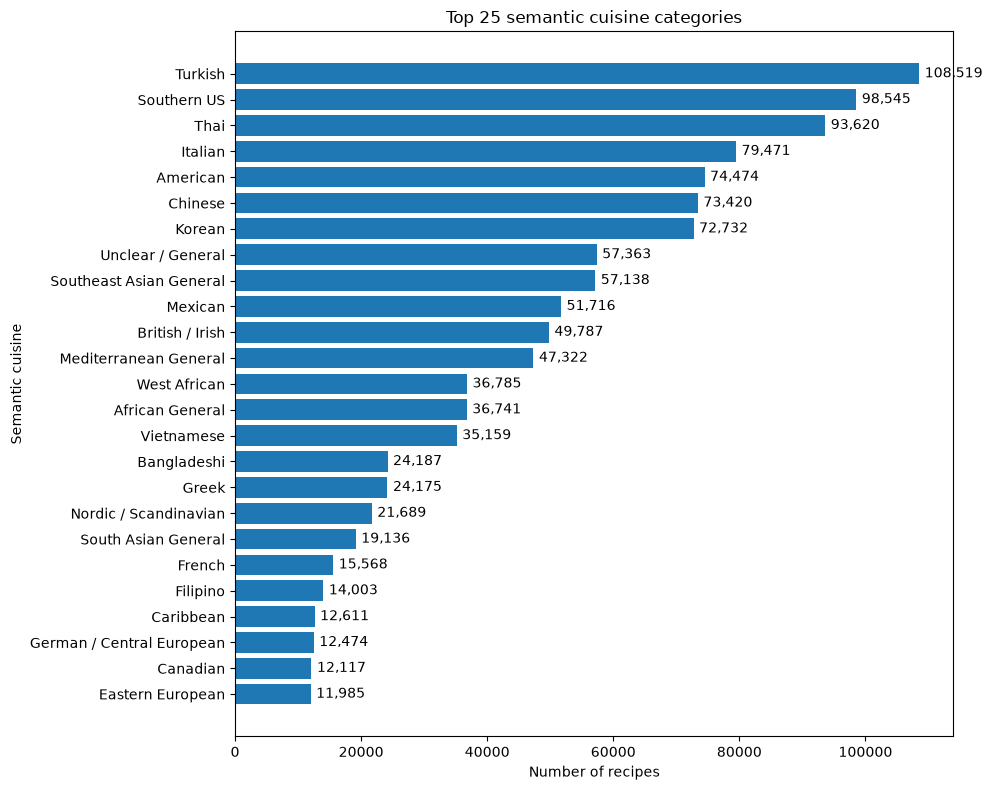

In [31]:
import matplotlib.pyplot as plt

top_n = 25

plot_df = (
    semantic_cuisine_stats
    .head(top_n)
    .sort_values("n_recipes", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(plot_df["semantic_cuisine"], plot_df["n_recipes"])

ax.set_xlabel("Number of recipes")
ax.set_ylabel("Semantic cuisine")
ax.set_title(f"Top {top_n} semantic cuisine categories")

ax.bar_label(bars, labels=[f"{v:,}" for v in plot_df["n_recipes"]], padding=4)

plt.tight_layout()
plt.show()

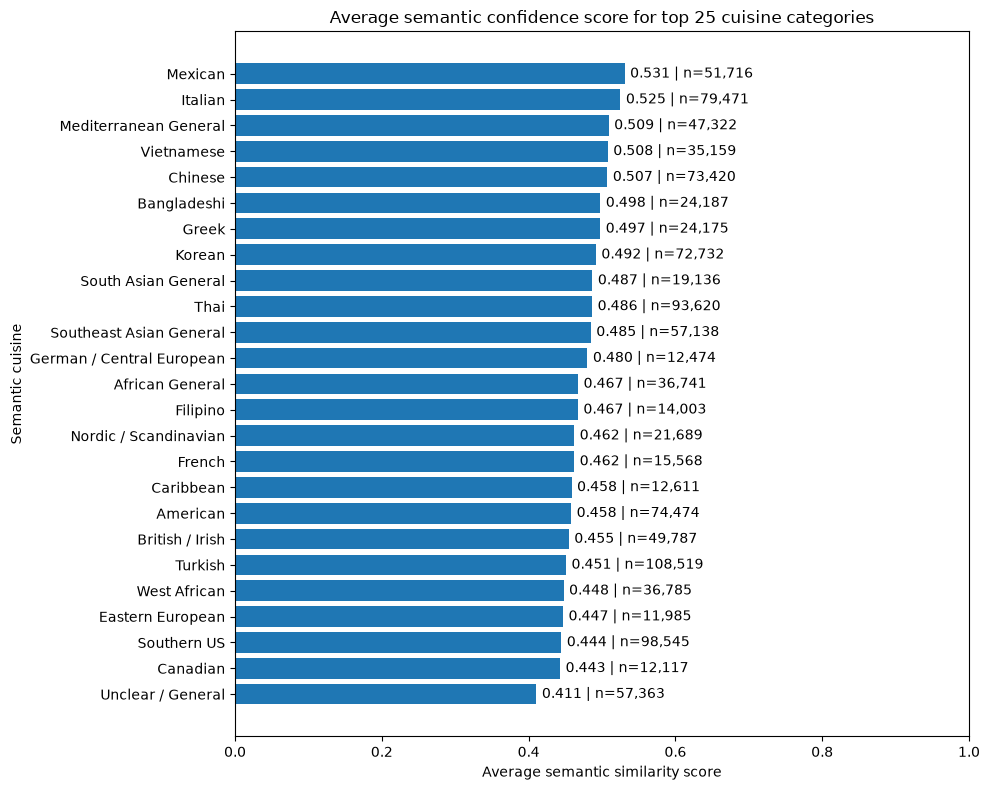

In [32]:
top_n = 25

plot_df = (
    semantic_cuisine_stats
    .head(top_n)
    .sort_values("avg_score", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(plot_df["semantic_cuisine"], plot_df["avg_score"])

ax.set_xlabel("Average semantic similarity score")
ax.set_ylabel("Semantic cuisine")
ax.set_title(f"Average semantic confidence score for top {top_n} cuisine categories")
ax.set_xlim(0, 1)

labels = [
    f"{score:.3f} | n={n:,}"
    for score, n in zip(plot_df["avg_score"], plot_df["n_recipes"])
]

ax.bar_label(bars, labels=labels, padding=4)

plt.tight_layout()
plt.show()

High-confidence recipes: 84345


,semantic_cuisine,n_recipes
0,Italian,16513
1,Mexican,14623
2,Chinese,8051
3,Mediterranean General,4845
4,Thai,4578
5,Korean,4212
6,American,4038
7,Southern US,3418
8,Turkish,2983
9,British / Irish,2241


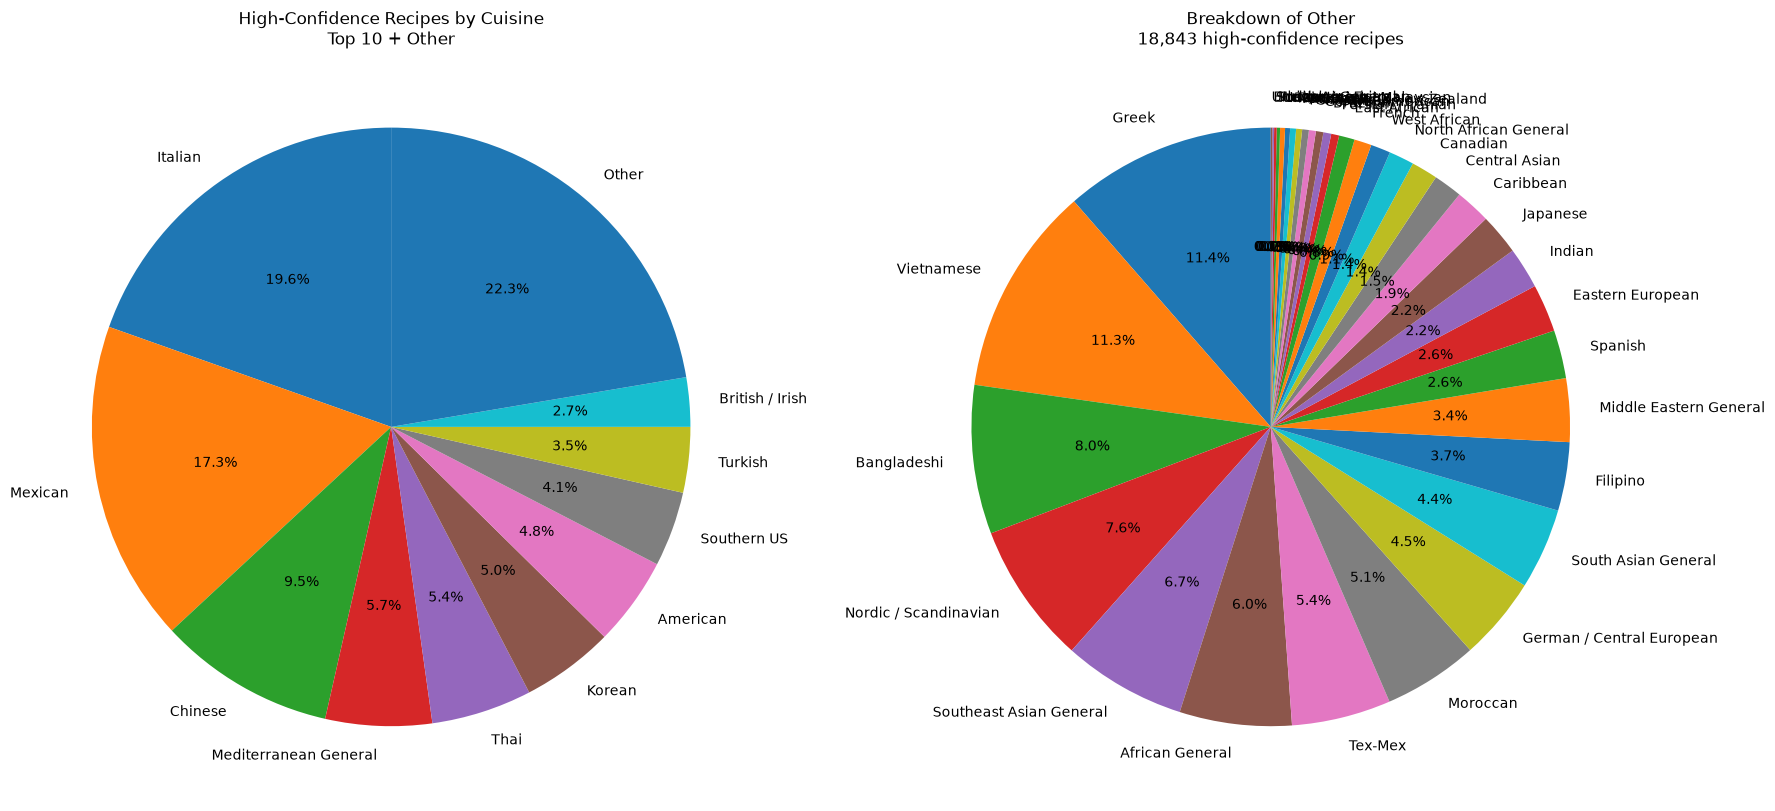

In [35]:
top_n = 10

# Keep only high-confidence semantic cuisine labels
high_conf_df = stats_df.loc[
    stats_df["semantic_cuisine_confidence"] == "high"
].copy()

high_conf_counts = (
    high_conf_df["semantic_cuisine"]
    .value_counts()
    .reset_index()
)

high_conf_counts.columns = ["semantic_cuisine", "n_recipes"]

print("High-confidence recipes:", len(high_conf_df))
display(high_conf_counts.head(30))

# Top cuisines for the main pie
top_counts = high_conf_counts.head(top_n).copy()

# Everything outside top_n becomes "Other" in the main pie
other_breakdown = high_conf_counts.iloc[top_n:].copy()
other_count = other_breakdown["n_recipes"].sum()

main_pie_counts = top_counts.copy()

if other_count > 0:
    main_pie_counts = pd.concat(
        [
            main_pie_counts,
            pd.DataFrame([{
                "semantic_cuisine": "Other",
                "n_recipes": other_count
            }])
        ],
        ignore_index=True
    )

# Create side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left chart: Top N + Other
axes[0].pie(
    main_pie_counts["n_recipes"],
    labels=main_pie_counts["semantic_cuisine"],
    autopct="%1.1f%%",
    startangle=90
)

axes[0].set_title(
    f"High-Confidence Recipes by Cuisine\nTop {top_n} + Other"
)

# Right chart: breakdown of Other
if other_count > 0:
    axes[1].pie(
        other_breakdown["n_recipes"],
        labels=other_breakdown["semantic_cuisine"],
        autopct="%1.1f%%",
        startangle=90
    )

    axes[1].set_title(
        f"Breakdown of Other\n{other_count:,} high-confidence recipes"
    )

else:
    axes[1].text(
        0.5,
        0.5,
        "No Other category",
        ha="center",
        va="center",
        fontsize=14
    )
    axes[1].set_title("Breakdown of Other")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

LM studio Qwen 3.6 35B second pass test

In [6]:
from pathlib import Path
import time
import json
import re
from datetime import datetime

import numpy as np
import pandas as pd

from openai import OpenAI

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 300)

# Notebook lives in scratch/EDA, so go two levels up to the Capstone repo root.
ROOT = Path.cwd().parents[1]

OUT_DIR = ROOT / "scratch" / "EDA" / "semantic_cuisine_labeling"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook cwd:", Path.cwd())
print("Project root:", ROOT)
print("Output dir:", OUT_DIR)

Notebook cwd: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA
Project root: c:\Users\winni\Documents\GitHub\Capstone\Capstone
Output dir: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling


Connect LM Studio

In [8]:
LM_STUDIO_BASE_URL = "http://10.0.0.2:1234/v1"

client = OpenAI(
    base_url=LM_STUDIO_BASE_URL,
    api_key="lm-studio"
)

models = client.models.list()

print("Available models:")
for model in models.data:
    print(model.id)

MODEL_NAME = models.data[0].id
print("\nUsing model:", MODEL_NAME)

Available models:
qwen/qwen3.6-35b-a3b
qwen/qwen3-vl-4b
openai/gpt-oss-20b
meta/llama-3.3-70b
openai/gpt-oss-120b
google/gemma-3-4b
text-embedding-nomic-embed-text-v1.5

Using model: qwen/qwen3.6-35b-a3b


Load Cuisine Taxonomy from earlier cell

In [8]:
taxonomy_df = pd.DataFrame(CUISINE_TAXONOMY)

allowed_cuisines = sorted(taxonomy_df["cuisine"].unique().tolist())
allowed_parent_cuisines = sorted(taxonomy_df["parent"].unique().tolist())

# Fusion components should be real cuisine labels, not meta-labels.
fusion_component_cuisines = [
    c for c in allowed_cuisines
    if c not in ["Fusion", "Unclear / General", "Other / Specific"]
]

print("Allowed cuisines:", len(allowed_cuisines))
print(allowed_cuisines)

print("\nAllowed parent cuisines:", len(allowed_parent_cuisines))
print(allowed_parent_cuisines)

Allowed cuisines: 46
['African General', 'American', 'Australian / New Zealand', 'Bangladeshi', 'Brazilian', 'British / Irish', 'Canadian', 'Caribbean', 'Central American', 'Central Asian', 'Chinese', 'East African', 'Eastern European', 'Ethiopian / Eritrean', 'Filipino', 'French', 'Fusion', 'German / Central European', 'Greek', 'Indian', 'Indonesian / Malaysian', 'Italian', 'Japanese', 'Korean', 'Levantine', 'Mediterranean General', 'Mexican', 'Middle Eastern General', 'Moroccan', 'Nordic / Scandinavian', 'North African General', 'Pakistani', 'Persian / Iranian', 'South American', 'South Asian General', 'Southeast Asian General', 'Southern US', 'Spanish', 'Sri Lankan', 'Taiwanese', 'Tex-Mex', 'Thai', 'Turkish', 'Unclear / General', 'Vietnamese', 'West African']

Allowed parent cuisines: 12
['African', 'Caribbean', 'Central Asian', 'East Asian', 'European', 'Global', 'Latin American', 'Middle Eastern', 'North African', 'South Asian', 'Southeast Asian', 'Western']


Load semantic first pass output

In [9]:
# Try to use an existing dataframe first.
if "stats_df" in globals() and stats_df is not None:
    llm_source_df = stats_df.copy()
elif "full_labeled" in globals() and full_labeled is not None:
    llm_source_df = full_labeled.copy()
else:
    # Fallback: load the expected semantic output.
    FULL_OUT_PATH = OUT_DIR / "recipes_trimmed_semantic_cuisine_labeled_no_cookbooks.parquet"
    llm_source_df = pd.read_parquet(FULL_OUT_PATH)

llm_source_df["recipe_id"] = llm_source_df["recipe_id"].astype(str)

print("Total semantic-labeled rows:", len(llm_source_df))
print("Columns:")
print(llm_source_df.columns.tolist())

display(llm_source_df.head())

Total semantic-labeled rows: 1229020
Columns:
['recipe_id', 'title', 'NER', 'link', 'source', 'link_str', 'semantic_text', 'semantic_parent_cuisine', 'semantic_cuisine', 'prototype_text', 'semantic_cuisine_score', 'semantic_cuisine_margin', 'semantic_cuisine_confidence', 'semantic_cuisine_method']


,recipe_id,title,NER,link,source,link_str,semantic_text,semantic_parent_cuisine,semantic_cuisine,prototype_text,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence,semantic_cuisine_method
0,896341,Deconstructed Screwdriver (The Raw Egg),"[""orange juice"", ""jiggers vodka""]",www.allrecipes.com/recipe/241895/deconstructed-screwdriver-the-raw-egg/,Gathered,www.allrecipes.com/recipe/241895/deconstructed-screwdriver-the-raw-egg/,Title: Deconstructed Screwdriver (The Raw Egg) | Ingredient names: orange juice jiggers vodka,East Asian,Taiwanese,bubble tea oyster omelette lu rou fan five spice,0.398102,0.020789,low,semantic_prototype_similarity
1,896342,Kettle Corn,"[""vegetable oil"", ""white sugar"", ""popcorn kernels""]",www.allrecipes.com/recipe/20808/kettle-corn/,Gathered,www.allrecipes.com/recipe/20808/kettle-corn/,Title: Kettle Corn | Ingredient names: vegetable oil white sugar popcorn kernels,Latin American,Central American,Salvadoran Guatemalan Honduran pupusas plantains beans corn,0.445732,0.039480,low,semantic_prototype_similarity
2,896343,Pop'S Fabulous Ajvar,"[""eggplants"", ""green bell peppers"", ""red bell peppers"", ""cooking spray"", ""garlic"", ""salt"", ""white vinegar"", ""corn oil""]",www.allrecipes.com/recipe/238733/pops-fabulous-ajvar/,Gathered,www.allrecipes.com/recipe/238733/pops-fabulous-ajvar/,Title: Pop'S Fabulous Ajvar | Ingredient names: eggplants green bell peppers red bell peppers cooking spray garlic salt white vinegar corn oil,East Asian,Taiwanese,bubble tea oyster omelette lu rou fan five spice,0.465672,0.010646,low,semantic_prototype_similarity
3,896344,Chipotle-Mango Guacamole,"[""avocados"", ""tomatoes"", ""mango"", ""cilantro"", ""red onion"", ""peppers"", ""pepper"", ""sour cream"", ""lime juice"", ""garlic"", ""cayenne pepper"", ""ground cumin"", ""black pepper""]",www.allrecipes.com/recipe/241254/chipotle-mango-guacamole/,Gathered,www.allrecipes.com/recipe/241254/chipotle-mango-guacamole/,Title: Chipotle-Mango Guacamole | Ingredient names: avocados tomatoes mango cilantro red onion peppers pepper sour cream lime juice garlic cayenne pepper ground cumin black pepper,Southeast Asian,Thai,fish sauce lemongrass galangal coconut milk curry paste basil lime,0.457709,0.011584,low,semantic_prototype_similarity
4,896345,Basic Homemade Ricotta Cheese,"[""milk"", ""heavy whipping cream"", ""white vinegar"", ""salt""]",www.allrecipes.com/recipe/261696/basic-homemade-ricotta-cheese/,Gathered,www.allrecipes.com/recipe/261696/basic-homemade-ricotta-cheese/,Title: Basic Homemade Ricotta Cheese | Ingredient names: milk heavy whipping cream white vinegar salt,Southeast Asian,Filipino,adobo lumpia pancit vinegar soy sauce calamansi,0.474099,0.073372,medium,semantic_prototype_similarity


Filter only high confidence for now

In [10]:
llm_input_df = llm_source_df.loc[
    llm_source_df["semantic_cuisine_confidence"] == "high"
].copy()

llm_input_df["recipe_id"] = llm_input_df["recipe_id"].astype(str)

print("Rows available for LLM second pass:", len(llm_input_df))

display(
    llm_input_df[
        [
            "recipe_id",
            "title",
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "semantic_cuisine_confidence",
        ]
    ].head(20)
)

Rows available for LLM second pass: 84345


,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence
6,896347,Navajo Tacos,Latin American,Mexican,0.581307,0.061942,high
21,896362,Dawn Fried Rice,South Asian,South Asian General,0.558453,0.056688,high
45,896390,Feta And Slow-Roasted Tomato Salad With French Green Beans,Global,Mediterranean General,0.604343,0.068394,high
47,896392,Italian Zucchini Soup,European,Italian,0.578753,0.102753,high
65,896411,"Chia Seed, Coconut, And Raspberry French Toast Sticks",African,West African,0.553079,0.065943,high
71,896417,Italian Tomato Pasta Salad,European,Italian,0.679675,0.133960,high
154,896513,Kikkoman Chinese Pepper Steak,East Asian,Chinese,0.594691,0.096053,high
168,896528,The Sriracha Chicken Marinade,Southeast Asian,Thai,0.552711,0.056936,high
186,896546,Tomato Alfredo Sauce With Artichokes,European,Italian,0.569310,0.065490,high
195,896556,Spicy Roasted Tomato And Ricotta Pasta Sauce,European,Italian,0.664705,0.106804,high


Build a blind recipe context

In [11]:
def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value)


def build_blind_recipe_context(row):
    title = safe_text(row.get("title", ""))
    ingredients = safe_text(row.get("ingredients", ""))
    ner = safe_text(row.get("NER", row.get("ner", "")))
    semantic_text = safe_text(row.get("semantic_text", ""))

    context = f"""
Recipe title:
{title}

Ingredients:
{ingredients}

Parsed ingredient names:
{ner}
""".strip()

    # Fallback if ingredients / NER are not present in the saved dataframe.
    # This should still be blind as long as semantic_text only contains title/ingredients.
    if len(context.strip()) < 50 and semantic_text:
        context = f"""
Recipe title:
{title}

Recipe text:
{semantic_text}
""".strip()

    return context

Build constrained LLM prompt

In [12]:
def build_blind_llm_cuisine_prompt(row):
    cuisine_list = "\n".join(f"- {x}" for x in allowed_cuisines)
    parent_list = "\n".join(f"- {x}" for x in allowed_parent_cuisines)
    fusion_component_list = "\n".join(f"- {x}" for x in fusion_component_cuisines)

    recipe_context = build_blind_recipe_context(row)

    return f"""
/no_think

You are classifying recipes by cuisine or cultural origin for a meal-planning dataset.

Use only the recipe title and ingredients. You are not given any prior model label or prior confidence score.

You must choose from the controlled labels below. Do not invent new broad labels.

Allowed cuisine labels:
{cuisine_list}

Allowed parent cuisine labels:
{parent_list}

Allowed fusion component labels:
{fusion_component_list}

Return valid JSON only. No markdown. No prose outside JSON.

JSON schema:
{{
  "cuisine": "one allowed cuisine label",
  "parent_cuisine": "one allowed parent cuisine label",
  "is_fusion": false,
  "fusion_components": [],
  "certainty_score": 0.0,
  "reason": "one short sentence",
  "evidence": ["title term or ingredient", "title term or ingredient"]
}}

Rules:
- Use exactly one value from Allowed cuisine labels for "cuisine".
- Use exactly one value from Allowed parent cuisine labels for "parent_cuisine".
- Use "Fusion" only when the recipe clearly combines two or more cuisine traditions.
- If "is_fusion" is true, set "cuisine" to "Fusion" and "parent_cuisine" to "Global".
- If "is_fusion" is true, list 2 to 4 labels from Allowed fusion component labels in "fusion_components".
- If "is_fusion" is false, "fusion_components" must be an empty list.
- Do not mark fusion just because a recipe has common global ingredients like garlic, onion, tomato, rice, chicken, beef, cheese, or pasta.
- Prefer the clearest specific cuisine when title and ingredient evidence are strong.
- Use broader/general labels only when the specific cuisine is unclear.
- If evidence is weak or generic, use "Unclear / General" and "parent_cuisine": "Global".
- Use "Other / Specific" only if the recipe clearly belongs to a cuisine not represented by the allowed labels.
- certainty_score must be a number from 0.0 to 1.0.
- Use high certainty only when the title and ingredient evidence agree.
- Lower certainty when the title is vague, ingredients are generic, or multiple cuisines are plausible.
- evidence should contain only short title terms or ingredients that influenced the decision.
- Do not include hidden reasoning or step-by-step reasoning.

Recipe:
{recipe_context}
""".strip()

JSON parser and validator

In [13]:
def parse_llm_json(text):
    text = str(text).strip()

    # Remove possible markdown fences.
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    # Extract JSON object if the model adds extra text.
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        text = match.group(0)

    return json.loads(text)


def validate_llm_cuisine_output(parsed):
    errors = []

    cuisine = parsed.get("cuisine")
    parent = parsed.get("parent_cuisine")
    is_fusion = parsed.get("is_fusion")
    fusion_components = parsed.get("fusion_components")
    certainty = parsed.get("certainty_score")
    evidence = parsed.get("evidence")

    if cuisine not in allowed_cuisines:
        errors.append(f"Invalid cuisine: {cuisine}")

    if parent not in allowed_parent_cuisines:
        errors.append(f"Invalid parent_cuisine: {parent}")

    if not isinstance(is_fusion, bool):
        errors.append("is_fusion must be boolean")

    if not isinstance(fusion_components, list):
        errors.append("fusion_components must be a list")

    if isinstance(fusion_components, list):
        invalid_components = [
            x for x in fusion_components
            if x not in fusion_component_cuisines
        ]
        if invalid_components:
            errors.append(f"Invalid fusion_components: {invalid_components}")

    try:
        certainty_float = float(certainty)
        if not (0 <= certainty_float <= 1):
            errors.append("certainty_score must be between 0 and 1")
    except Exception:
        errors.append("certainty_score must be numeric")

    if is_fusion is True:
        if cuisine != "Fusion":
            errors.append("Fusion recipes must use cuisine='Fusion'")
        if parent != "Global":
            errors.append("Fusion recipes should use parent_cuisine='Global'")
        if not isinstance(fusion_components, list) or len(fusion_components) < 2:
            errors.append("Fusion recipes should have at least 2 fusion_components")

    if is_fusion is False:
        if fusion_components not in [[], None]:
            errors.append("Non-fusion recipes should have empty fusion_components")

    if evidence is not None and not isinstance(evidence, list):
        errors.append("evidence must be a list")

    return errors

Function for tagging one recipe

In [12]:
def tag_recipe_blind_with_llm(row, model_name=MODEL_NAME, sleep_seconds=0.0):
    prompt = build_blind_llm_cuisine_prompt(row)

    result = {
        "recipe_id": row["recipe_id"],
        "llm_model": model_name,
        "llm_ts": datetime.now().isoformat(timespec="seconds"),
        "llm_cuisine": None,
        "llm_parent_cuisine": None,
        "llm_is_fusion": None,
        "llm_fusion_components": None,
        "llm_certainty_score": None,
        "llm_reason": None,
        "llm_evidence": None,
        "llm_raw_response": None,
        "llm_validation_errors": None,
        "llm_error": None,
    }

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You classify recipe cuisine using only the provided title and ingredients. "
                        "Return valid JSON only. Follow the controlled label set exactly. "
                        "Do not reveal reasoning."
                    ),
                },
                {
                    "role": "user",
                    "content": prompt,
                },
            ],
            temperature=0.0,
            top_p=0.9,
            max_tokens=350,
        )

        raw_text = response.choices[0].message.content
        result["llm_raw_response"] = raw_text

        parsed = parse_llm_json(raw_text)
        validation_errors = validate_llm_cuisine_output(parsed)

        result.update({
            "llm_cuisine": parsed.get("cuisine"),
            "llm_parent_cuisine": parsed.get("parent_cuisine"),
            "llm_is_fusion": parsed.get("is_fusion"),
            "llm_fusion_components": parsed.get("fusion_components"),
            "llm_certainty_score": parsed.get("certainty_score"),
            "llm_reason": parsed.get("reason"),
            "llm_evidence": parsed.get("evidence"),
            "llm_validation_errors": validation_errors if validation_errors else None,
        })

    except Exception as e:
        result["llm_error"] = repr(e)

    if sleep_seconds:
        time.sleep(sleep_seconds)

    return result

test small high confidence sample

In [15]:
N_TEST = 25

llm_input_test = (
    llm_input_df
    .sample(min(N_TEST, len(llm_input_df)), random_state=42)
    .copy()
)

print("LLM test rows:", len(llm_input_test))

llm_test_results = []

for i, (_, row) in enumerate(llm_input_test.iterrows(), start=1):
    print(f"Tagging test {i}/{len(llm_input_test)} | recipe_id={row['recipe_id']} | title={row.get('title', '')}")
    result = tag_recipe_blind_with_llm(row)
    llm_test_results.append(result)

llm_test_df = pd.DataFrame(llm_test_results)

display(
    llm_test_df[
        [
            "recipe_id",
            "llm_cuisine",
            "llm_parent_cuisine",
            "llm_is_fusion",
            "llm_fusion_components",
            "llm_certainty_score",
            "llm_reason",
            "llm_evidence",
            "llm_validation_errors",
            "llm_error",
            "llm_raw_response",
        ]
    ]
)

LLM test rows: 25
Tagging test 1/25 | recipe_id=1284241 | title=Greek Pasta Salad With Vinaigrette 
Tagging test 2/25 | recipe_id=2123948 | title=Bean Sprouts With Sesame Vingar Soy Sauce
Tagging test 3/25 | recipe_id=1726465 | title=Turkey Tetrazzini Crisp
Tagging test 4/25 | recipe_id=1408421 | title=Creamy Eggplant Dip
Tagging test 5/25 | recipe_id=1442047 | title=Tequila Barbecue Sauce
Tagging test 6/25 | recipe_id=2117893 | title=Keralan Stir-Fried Beets
Tagging test 7/25 | recipe_id=1235186 | title=Golumpki - Polish Stuffed Cabbage Rolls
Tagging test 8/25 | recipe_id=1199774 | title=Indian Seer Fish Fry
Tagging test 9/25 | recipe_id=1418445 | title=Short Rib Cheesesteak Sandwiches
Tagging test 10/25 | recipe_id=2196396 | title=Country Recipe Biscuits
Tagging test 11/25 | recipe_id=1943742 | title=Oven BBQ Ribs
Tagging test 12/25 | recipe_id=1750783 | title=Guiltless Quiche Parmigiano
Tagging test 13/25 | recipe_id=1772722 | title=Toasted Spaghetti Minestra with Tuscan Kale
Taggin

,recipe_id,llm_cuisine,llm_parent_cuisine,llm_is_fusion,llm_fusion_components,llm_certainty_score,llm_reason,llm_evidence,llm_validation_errors,llm_error,llm_raw_response
0,1284241,Greek,European,False,[],0.90,The title explicitly states 'Greek' and the ingredients include signature Greek items like Kalamata olives and oregano.,"[Greek Pasta Salad With Vinaigrette, chopped/ pitted Kalamata olives, oregano]",None,None,"{\n ""cuisine"": ""Greek"",\n ""parent_cuisine"": ""European"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.9,\n ""reason"": ""The title explicitly states 'Greek' and the ingredients include signature Greek items like Kalamata olives and oregano."",\n ""evidence"": [\n ""G..."
1,2123948,Chinese,East Asian,False,[],0.80,"The combination of bean sprouts, vinegar, and soy sauce is characteristic of Chinese stir-fry or salad preparations.","[Bean Sprouts, Soy Sauce, Vingar]",None,None,"{\n ""cuisine"": ""Chinese"",\n ""parent_cuisine"": ""East Asian"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.8,\n ""reason"": ""The combination of bean sprouts, vinegar, and soy sauce is characteristic of Chinese stir-fry or salad preparations."",\n ""evidence"": [\n ""..."
2,1726465,American,Global,False,[],0.80,"The dish name 'Turkey Tetrazzini' refers to a classic American pasta casserole, and the ingredients like pasta, turkey, and breadcrumbs are standard for this comfort food style.","[Turkey Tetrazzini Crisp, pasta, ground turkey, bread crumbs]",None,None,"{\n ""cuisine"": ""American"",\n ""parent_cuisine"": ""Global"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.8,\n ""reason"": ""The dish name 'Turkey Tetrazzini' refers to a classic American pasta casserole, and the ingredients like pasta, turkey, and breadcrumbs are stand..."
3,1408421,Levantine,Middle Eastern,False,[],0.85,"The combination of eggplant, garlic, lemon, olive oil, and oregano strongly suggests a Levantine or Mediterranean eggplant dip, likely a variation of Baba Ganoush.","[eggplants, garlic, lemon, olive oil, oregano]",None,None,"{\n ""cuisine"": ""Levantine"",\n ""parent_cuisine"": ""Middle Eastern"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.85,\n ""reason"": ""The combination of eggplant, garlic, lemon, olive oil, and oregano strongly suggests a Levantine or Mediterranean eggplant dip, likely ..."
4,1442047,Mexican,Latin American,False,[],0.80,"The combination of tequila, tomato paste, and hot sauce strongly suggests a Mexican or Tex-Mex flavor profile.","[Tequila Barbecue Sauce, tequila, hot sauce, tomato paste]",None,None,"{\n ""cuisine"": ""Mexican"",\n ""parent_cuisine"": ""Latin American"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.8,\n ""reason"": ""The combination of tequila, tomato paste, and hot sauce strongly suggests a Mexican or Tex-Mex flavor profile."",\n ""evidence"": [\n ""Te..."
5,2117893,Indian,South Asian,False,[],0.90,"The title explicitly mentions 'Keralan', a region in India, and the ingredients include classic South Indian tempering spices like mustard seeds, curry leaves (implied by curry), and coconut.","[Keralan, mustard seeds, coconut, turmeric, curry]",None,None,"{\n ""cuisine"": ""Indian"",\n ""parent_cuisine"": ""South Asian"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.9,\n ""reason"": ""The title explicitly mentions 'Keralan', a region in India, and the ingredients include classic South Indian tempering spices like mustard see..."
6,1235186,Eastern European,European,False,[],0.95,"The title explicitly identifies the dish as Polish, and the ingredients of stuffed cabbage with rice and meat are characteristic of this Eastern European cuisine.","[Polish, Stuffed Cabbage Rolls, cabbage, rice, ground beef]",None,None,"{\n ""cuisine"": ""Eastern European"",\n ""parent_cuisine"": ""European"",\n ""is_fusion"": false,\n ""fus

review results

In [16]:
review_test_df = llm_input_test.merge(
    llm_test_df,
    on="recipe_id",
    how="left"
)

display(
    review_test_df[
        [
            "recipe_id",
            "title",
            "semantic_text",
            "llm_cuisine",
            "llm_parent_cuisine",
            "llm_is_fusion",
            "llm_fusion_components",
            "llm_certainty_score",
            "llm_reason",
            "llm_evidence",
            "llm_validation_errors",
            "llm_error",
        ]
    ]
)

,recipe_id,title,semantic_text,llm_cuisine,llm_parent_cuisine,llm_is_fusion,llm_fusion_components,llm_certainty_score,llm_reason,llm_evidence,llm_validation_errors,llm_error
0,1284241,Greek Pasta Salad With Vinaigrette,Title: Greek Pasta Salad With Vinaigrette | Ingredient names: bowtie pasta tomatoes chopped/ peeled/ chopped/ pitted Kalamata olives fresh basil Vinaigrette red wine vinegar mustard garlic Salt oregano thyme tsps sugar EVOO,Greek,European,False,[],0.90,The title explicitly states 'Greek' and the ingredients include signature Greek items like Kalamata olives and oregano.,"[Greek Pasta Salad With Vinaigrette, chopped/ pitted Kalamata olives, oregano]",None,None
1,2123948,Bean Sprouts With Sesame Vingar Soy Sauce,Title: Bean Sprouts With Sesame Vingar Soy Sauce | Ingredient names: sprouts Grain vinegar Honey,Chinese,East Asian,False,[],0.80,"The combination of bean sprouts, vinegar, and soy sauce is characteristic of Chinese stir-fry or salad preparations.","[Bean Sprouts, Soy Sauce, Vingar]",None,None
2,1726465,Turkey Tetrazzini Crisp,Title: Turkey Tetrazzini Crisp | Ingredient names: Vegetable oil cooking spray pasta Kosher salt unsalted butter ground turkey Freshly ground black pepper all-purpose milk chicken stock cayenne pepper freshly ground nutmeg fresh sage bread crumbs Parmesan unsalted butter,American,Global,False,[],0.80,"The dish name 'Turkey Tetrazzini' refers to a classic American pasta casserole, and the ingredients like pasta, turkey, and breadcrumbs are standard for this comfort food style.","[Turkey Tetrazzini Crisp, pasta, ground turkey, bread crumbs]",None,None
3,1408421,Creamy Eggplant Dip,Title: Creamy Eggplant Dip | Ingredient names: eggplants scallions garlic oregano Greek yogurt lemon salt olive oil,Levantine,Middle Eastern,False,[],0.85,"The combination of eggplant, garlic, lemon, olive oil, and oregano strongly suggests a Levantine or Mediterranean eggplant dip, likely a variation of Baba Ganoush.","[eggplants, garlic, lemon, olive oil, oregano]",None,None
4,1442047,Tequila Barbecue Sauce,Title: Tequila Barbecue Sauce | Ingredient names: pineapple tomato paste tequila lemon juice white vinegar garlic hot sauce,Mexican,Latin American,False,[],0.80,"The combination of tequila, tomato paste, and hot sauce strongly suggests a Mexican or Tex-Mex flavor profile.","[Tequila Barbecue Sauce, tequila, hot sauce, tomato paste]",None,None
5,2117893,Keralan Stir-Fried Beets,Title: Keralan Stir-Fried Beets | Ingredient names: coconut garlic serrano salt ground cumin cayenne pepper turmeric water vegetable oil mustard seeds red chiles curry long-grain rice beets,Indian,South Asian,False,[],0.90,"The title explicitly mentions 'Keralan', a region in India, and the ingredients include classic South Indian tempering spices like mustard seeds, curry leaves (implied by curry), and coconut.","[Keralan, mustard seeds, coconut, turmeric, curry]",None,None
6,1235186,Golumpki - Polish Stuffed Cabbage Rolls,Title: Golumpki - Polish Stuffed Cabbage Rolls | Ingredient names: rice ground beef onion water salt pepper garlic tomato juice mushroom soup cabbage,Eastern European,European,False,[],0.95,"The title explicitly identifies the dish as Polish, and the ingredients of stuffed cabbage with rice and meat are characteristic of this Eastern European cuisine.","[Polish, Stuffed Cabbage Rolls, cabbage, rice, ground beef]",None,None
7,1199774,Indian Seer Fish Fry,Title: Indian Seer Fish Fry | Ingredient names: fish turmeric powder red chili powder ginger-garlic black pepper lemon juice oil salt,Indian,South Asian,False,[],0.95,"The title explicitly states 'Indian' and the ingredients like turmeric, red chili powder, and ginger-garlic paste are characteristic of Indian cooking.","[Indian Seer Fish Fry, turmeric powder, red chili powder, ginger-garlic]",None,None
8,1418445,Short Rib Cheesesteak Sandwiches,Title: Short Rib Cheesesteak Sandwiches | Ingredient names: bread milk flour mustard salt cheddar cheese olive oil onion

set checkpoint for full run (high confidence)

In [5]:
LLM_SECOND_PASS_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_cuisine_labels_checkpoint.csv"

print("Checkpoint path:", LLM_SECOND_PASS_OUT)

Checkpoint path: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_blind_high_confidence_cuisine_labels_checkpoint.csv


resume if checkpoint exists

In [16]:
# Delete the empty/corrupted LLM checkpoint directly.
# This does NOT try to read the CSV.

from pathlib import Path

LLM_SECOND_PASS_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_cuisine_labels_checkpoint.csv"

print("Checkpoint path:", LLM_SECOND_PASS_OUT)
print("Exists before:", LLM_SECOND_PASS_OUT.exists())

if LLM_SECOND_PASS_OUT.exists():
    print("File size bytes:", LLM_SECOND_PASS_OUT.stat().st_size)
    LLM_SECOND_PASS_OUT.unlink()
    print("Deleted checkpoint.")

print("Exists after:", LLM_SECOND_PASS_OUT.exists())

Checkpoint path: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_blind_high_confidence_cuisine_labels_checkpoint.csv
Exists before: True
File size bytes: 2
Deleted checkpoint.
Exists after: False


Create 1,000 recipe subset

In [19]:
N_SUBSET = 1_000
RANDOM_STATE = 42

llm_input_subset = (
    llm_input_df
    .sample(
        n=min(N_SUBSET, len(llm_input_df)),
        random_state=RANDOM_STATE
    )
    .copy()
)

llm_input_subset["recipe_id"] = llm_input_subset["recipe_id"].astype(str)

print("Subset rows selected:", len(llm_input_subset))

display(
    llm_input_subset[
        [
            "recipe_id",
            "title",
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "semantic_cuisine_confidence",
        ]
    ].head(20)
)

Subset rows selected: 1000


,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence
357770,1284241,Greek Pasta Salad With Vinaigrette,European,Italian,0.587909,0.089746,high
1130063,2123948,Bean Sprouts With Sesame Vingar Soy Sauce,Southeast Asian,Filipino,0.610166,0.082335,high
763931,1726465,Turkey Tetrazzini Crisp,Middle Eastern,Turkish,0.585431,0.104166,high
474210,1408421,Creamy Eggplant Dip,Middle Eastern,Turkish,0.602474,0.132385,high
505225,1442047,Tequila Barbecue Sauce,Southeast Asian,Thai,0.571279,0.084957,high
1124504,2117893,Keralan Stir-Fried Beets,African,West African,0.574001,0.080308,high
314220,1235186,Golumpki - Polish Stuffed Cabbage Rolls,East Asian,Korean,0.552086,0.080619,high
281385,1199774,Indian Seer Fish Fry,South Asian,Bangladeshi,0.631864,0.136136,high
483582,1418445,Short Rib Cheesesteak Sandwiches,Western,American,0.592220,0.183002,high
1196991,2196396,Country Recipe Biscuits,Western,Southern US,0.573530,0.148378,high


run blind llm pass on 1,000

In [20]:
LLM_SUBSET_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_subset_1000.csv"

# Resume if subset checkpoint already exists
if LLM_SUBSET_OUT.exists():
    subset_completed_df = pd.read_csv(LLM_SUBSET_OUT)
    subset_completed_df["recipe_id"] = subset_completed_df["recipe_id"].astype(str)

    subset_completed_ids = set(subset_completed_df["recipe_id"])
    subset_llm_results = subset_completed_df.to_dict("records")

    print(f"Loaded subset checkpoint with {len(subset_completed_ids):,} completed recipes.")
else:
    subset_completed_ids = set()
    subset_llm_results = []

    print("No subset checkpoint found. Starting fresh.")

subset_rows_to_tag = llm_input_subset.loc[
    ~llm_input_subset["recipe_id"].isin(subset_completed_ids)
].copy()

print("Subset input rows:", len(llm_input_subset))
print("Completed subset rows:", len(subset_completed_ids))
print("Subset rows remaining:", len(subset_rows_to_tag))

SAVE_EVERY = 25
SLEEP_SECONDS = 0.0

start_time = time.perf_counter()

for i, (_, row) in enumerate(subset_rows_to_tag.iterrows(), start=1):
    print(
        f"Subset tagging {i}/{len(subset_rows_to_tag)} | "
        f"recipe_id={row['recipe_id']} | "
        f"title={row.get('title', '')}"
    )

    result = tag_recipe_blind_with_llm(
        row,
        model_name=MODEL_NAME,
        sleep_seconds=SLEEP_SECONDS,
    )

    subset_llm_results.append(result)

    if i % SAVE_EVERY == 0:
        pd.DataFrame(subset_llm_results).to_csv(LLM_SUBSET_OUT, index=False)

        elapsed = time.perf_counter() - start_time
        recipes_per_second = i / elapsed if elapsed > 0 else 0
        remaining = len(subset_rows_to_tag) - i
        estimated_remaining_minutes = remaining / recipes_per_second / 60 if recipes_per_second > 0 else None

        print(f"Subset checkpoint saved: {LLM_SUBSET_OUT}")
        print(f"Elapsed: {elapsed / 60:.1f} min")
        if estimated_remaining_minutes is not None:
            print(f"Estimated remaining: {estimated_remaining_minutes:.1f} min")

# Final subset save
llm_subset_df = pd.DataFrame(subset_llm_results)
llm_subset_df.to_csv(LLM_SUBSET_OUT, index=False)

elapsed = time.perf_counter() - start_time

print("Final subset checkpoint saved:", LLM_SUBSET_OUT)
print(f"Elapsed: {elapsed / 60:.1f} minutes")
print("Subset rows saved:", len(llm_subset_df))

display(llm_subset_df.head())

No subset checkpoint found. Starting fresh.
Subset input rows: 1000
Completed subset rows: 0
Subset rows remaining: 1000
Subset tagging 1/1000 | recipe_id=1284241 | title=Greek Pasta Salad With Vinaigrette 
Subset tagging 2/1000 | recipe_id=2123948 | title=Bean Sprouts With Sesame Vingar Soy Sauce
Subset tagging 3/1000 | recipe_id=1726465 | title=Turkey Tetrazzini Crisp
Subset tagging 4/1000 | recipe_id=1408421 | title=Creamy Eggplant Dip
Subset tagging 5/1000 | recipe_id=1442047 | title=Tequila Barbecue Sauce
Subset tagging 6/1000 | recipe_id=2117893 | title=Keralan Stir-Fried Beets
Subset tagging 7/1000 | recipe_id=1235186 | title=Golumpki - Polish Stuffed Cabbage Rolls
Subset tagging 8/1000 | recipe_id=1199774 | title=Indian Seer Fish Fry
Subset tagging 9/1000 | recipe_id=1418445 | title=Short Rib Cheesesteak Sandwiches
Subset tagging 10/1000 | recipe_id=2196396 | title=Country Recipe Biscuits
Subset tagging 11/1000 | recipe_id=1943742 | title=Oven BBQ Ribs
Subset tagging 12/1000 | 

,recipe_id,llm_model,llm_ts,llm_cuisine,llm_parent_cuisine,llm_is_fusion,llm_fusion_components,llm_certainty_score,llm_reason,llm_evidence,llm_raw_response,llm_validation_errors,llm_error
0,1284241,qwen/qwen3.6-35b-a3b,2026-06-20T20:20:44,Greek,European,False,[],0.90,The title explicitly states 'Greek' and the ingredients include signature Greek items like Kalamata olives and oregano.,"[Greek Pasta Salad With Vinaigrette, chopped/ pitted Kalamata olives, oregano]","{\n ""cuisine"": ""Greek"",\n ""parent_cuisine"": ""European"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.9,\n ""reason"": ""The title explicitly states 'Greek' and the ingredients include signature Greek items like Kalamata olives and oregano."",\n ""evidence"": [\n ""G...",None,None
1,2123948,qwen/qwen3.6-35b-a3b,2026-06-20T20:20:46,Chinese,East Asian,False,[],0.80,"The combination of bean sprouts, vinegar, and soy sauce is characteristic of Chinese stir-fry or salad preparations.","[Bean Sprouts, Soy Sauce, Vingar]","{\n ""cuisine"": ""Chinese"",\n ""parent_cuisine"": ""East Asian"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.8,\n ""reason"": ""The combination of bean sprouts, vinegar, and soy sauce is characteristic of Chinese stir-fry or salad preparations."",\n ""evidence"": [\n ""...",None,None
2,1726465,qwen/qwen3.6-35b-a3b,2026-06-20T20:20:47,American,Global,False,[],0.80,"The dish name 'Turkey Tetrazzini' refers to a classic American pasta casserole, and the ingredients like pasta, turkey, and breadcrumbs are standard for this comfort food style.","[Turkey Tetrazzini Crisp, pasta, ground turkey, bread crumbs]","{\n ""cuisine"": ""American"",\n ""parent_cuisine"": ""Global"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.8,\n ""reason"": ""The dish name 'Turkey Tetrazzini' refers to a classic American pasta casserole, and the ingredients like pasta, turkey, and breadcrumbs are stand...",None,None
3,1408421,qwen/qwen3.6-35b-a3b,2026-06-20T20:20:48,Levantine,Middle Eastern,False,[],0.85,"The combination of eggplant, garlic, lemon, olive oil, and oregano strongly suggests a Levantine or Mediterranean eggplant dip, likely a variation of Baba Ganoush.","[eggplants, garlic, lemon, olive oil, oregano]","{\n ""cuisine"": ""Levantine"",\n ""parent_cuisine"": ""Middle Eastern"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.85,\n ""reason"": ""The combination of eggplant, garlic, lemon, olive oil, and oregano strongly suggests a Levantine or Mediterranean eggplant dip, likely ...",None,None
4,1442047,qwen/qwen3.6-35b-a3b,2026-06-20T20:20:50,Mexican,Latin American,False,[],0.80,"The combination of tequila, tomato paste, and hot sauce strongly suggests a Mexican or Tex-Mex flavor profile.","[Tequila Barbecue Sauce, tequila, hot sauce, tomato paste]","{\n ""cuisine"": ""Mexican"",\n ""parent_cuisine"": ""Latin American"",\n ""is_fusion"": false,\n ""fusion_components"": [],\n ""certainty_score"": 0.8,\n ""reason"": ""The combination of tequila, tomato paste, and hot sauce strongly suggests a Mexican or Tex-Mex flavor profile."",\n ""evidence"": [\n ""Te...",None,None


compare 1,000 LLM labels to semantic labels

In [21]:
llm_subset_df = pd.read_csv(LLM_SUBSET_OUT)
llm_subset_df["recipe_id"] = llm_subset_df["recipe_id"].astype(str)

llm_subset_df["llm_certainty_score"] = pd.to_numeric(
    llm_subset_df["llm_certainty_score"],
    errors="coerce"
)

subset_comparison_df = llm_input_subset.merge(
    llm_subset_df,
    on="recipe_id",
    how="left"
)

# Exact cuisine agreement
subset_comparison_df["semantic_llm_exact_agree"] = (
    subset_comparison_df["semantic_cuisine"].astype(str)
    == subset_comparison_df["llm_cuisine"].astype(str)
)

# Parent-level agreement
subset_comparison_df["semantic_llm_parent_agree"] = (
    subset_comparison_df["semantic_parent_cuisine"].astype(str)
    == subset_comparison_df["llm_parent_cuisine"].astype(str)
)

# Helper to parse fusion components from CSV-loaded strings
def parse_listish(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    text = str(value).strip()
    if text in ["", "None", "nan", "[]"]:
        return []
    try:
        parsed = json.loads(text.replace("'", '"'))
        return parsed if isinstance(parsed, list) else []
    except Exception:
        try:
            import ast
            parsed = ast.literal_eval(text)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []

subset_comparison_df["llm_fusion_components_parsed"] = (
    subset_comparison_df["llm_fusion_components"]
    .apply(parse_listish)
)

# Fusion-aware agreement:
# Counts as agreement if:
# 1. LLM cuisine exactly matches semantic cuisine, OR
# 2. LLM marked Fusion and one of the fusion components matches the semantic cuisine.
subset_comparison_df["semantic_llm_fusion_aware_agree"] = subset_comparison_df.apply(
    lambda row: (
        row["semantic_llm_exact_agree"]
        or (
            row.get("llm_is_fusion") in [True, "True", "true", 1, "1"]
            and str(row["semantic_cuisine"]) in row["llm_fusion_components_parsed"]
        )
    ),
    axis=1
)

subset_comparison_df["llm_has_error"] = subset_comparison_df["llm_error"].notna()
subset_comparison_df["llm_has_validation_error"] = subset_comparison_df["llm_validation_errors"].notna()

print("Subset comparison rows:", len(subset_comparison_df))
print("Exact cuisine agreement:", subset_comparison_df["semantic_llm_exact_agree"].mean())
print("Fusion-aware cuisine agreement:", subset_comparison_df["semantic_llm_fusion_aware_agree"].mean())
print("Parent cuisine agreement:", subset_comparison_df["semantic_llm_parent_agree"].mean())
print("Average LLM certainty:", subset_comparison_df["llm_certainty_score"].mean())
print("LLM errors:", subset_comparison_df["llm_has_error"].sum())
print("LLM validation errors:", subset_comparison_df["llm_has_validation_error"].sum())

display(
    subset_comparison_df[
        [
            "recipe_id",
            "title",
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "semantic_cuisine_confidence",
            "llm_parent_cuisine",
            "llm_cuisine",
            "llm_is_fusion",
            "llm_fusion_components",
            "llm_certainty_score",
            "semantic_llm_exact_agree",
            "semantic_llm_fusion_aware_agree",
            "semantic_llm_parent_agree",
            "llm_reason",
            "llm_evidence",
            "llm_validation_errors",
            "llm_error",
        ]
    ].head(50)
)

Subset comparison rows: 1000
Exact cuisine agreement: 0.557
Fusion-aware cuisine agreement: 0.568
Parent cuisine agreement: 0.593
Average LLM certainty: 0.8204000000000001
LLM errors: 0
LLM validation errors: 113


,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence,llm_parent_cuisine,llm_cuisine,llm_is_fusion,llm_fusion_components,llm_certainty_score,semantic_llm_exact_agree,semantic_llm_fusion_aware_agree,semantic_llm_parent_agree,llm_reason,llm_evidence,llm_validation_errors,llm_error
0,1284241,Greek Pasta Salad With Vinaigrette,European,Italian,0.587909,0.089746,high,European,Greek,False,[],0.90,False,False,True,The title explicitly states 'Greek' and the ingredients include signature Greek items like Kalamata olives and oregano.,"['Greek Pasta Salad With Vinaigrette', 'chopped/ pitted Kalamata olives', 'oregano']",NaN,NaN
1,2123948,Bean Sprouts With Sesame Vingar Soy Sauce,Southeast Asian,Filipino,0.610166,0.082335,high,East Asian,Chinese,False,[],0.80,False,False,False,"The combination of bean sprouts, vinegar, and soy sauce is characteristic of Chinese stir-fry or salad preparations.","['Bean Sprouts', 'Soy Sauce', 'Vingar']",NaN,NaN
2,1726465,Turkey Tetrazzini Crisp,Middle Eastern,Turkish,0.585431,0.104166,high,Global,American,False,[],0.80,False,False,False,"The dish name 'Turkey Tetrazzini' refers to a classic American pasta casserole, and the ingredients like pasta, turkey, and breadcrumbs are standard for this comfort food style.","['Turkey Tetrazzini Crisp', 'pasta', 'ground turkey', 'bread crumbs']",NaN,NaN
3,1408421,Creamy Eggplant Dip,Middle Eastern,Turkish,0.602474,0.132385,high,Middle Eastern,Levantine,False,[],0.85,False,False,True,"The combination of eggplant, garlic, lemon, olive oil, and oregano strongly suggests a Levantine or Mediterranean eggplant dip, likely a variation of Baba Ganoush.","['eggplants', 'garlic', 'lemon', 'olive oil', 'oregano']",NaN,NaN
4,1442047,Tequila Barbecue Sauce,Southeast Asian,Thai,0.571279,0.084957,high,Latin American,Mexican,False,[],0.80,False,False,False,"The combination of tequila, tomato paste, and hot sauce strongly suggests a Mexican or Tex-Mex flavor profile.","['Tequila Barbecue Sauce', 'tequila', 'hot sauce', 'tomato paste']",NaN,NaN
5,2117893,Keralan Stir-Fried Beets,African,West African,0.574001,0.080308,high,South Asian,Indian,False,[],0.90,False,False,False,"The title explicitly mentions 'Keralan', a region in India, and the ingredients include classic South Indian tempering spices like mustard seeds, curry leaves (implied by curry), and coconut.","['Keralan', 'mustard seeds', 'coconut', 'turmeric', 'curry']",NaN,NaN
6,1235186,Golumpki - Polish Stuffed Cabbage Rolls,East Asian,Korean,0.552086,0.080619,high,European,Eastern European,False,[],0.95,False,False,False,"The title explicitly identifies the dish as Polish, and the ingredients of stuffed cabbage with rice and meat are characteristic of this Eastern European cuisine.","['Polish', 'Stuffed Cabbage Rolls', 'cabbage', 'rice', 'ground beef']",NaN,NaN
7,1199774,Indian Seer Fish Fry,South Asian,Bangladeshi,0.631864,0.136136,high,South Asian,Indian,False,[],0.95,False,False,True,"The title explicitly states 'Indian' and the ingredients like turmeric, red chili powder, and ginger-garlic paste are characteristic of Indian cooking.","['Indian Seer Fish Fry', 'turmeric powder', 'red chili powder', 'ginger-garlic']",NaN,NaN
8,1418445,Short Rib Cheesesteak Sandwiches,Western,American,0.592220,0.183002,high,Global,American,False,[],0.90,True,True,False,"The title explicitly references a 'Cheesesteak', which is a signature dish of Philadelphia, USA, supported by ingredients like short ribs, cheese, and bread.","['Short Rib Cheesesteak Sandwiches', 'cheddar cheese', 'short ribs', 'bread']",NaN,NaN
9,2196396,Country Recipe Biscuits,Western,Southern US,0.573530,0.148378,high,Western,American,False,[],0.90,False,False,True,"The combination of biscuits, buttermilk, and ranch dressing is a hallmark of Southern US comfort food.","['Biscuits', 'buttermilk', 'ranch dressing']",NaN,NaN


Summary tables

In [22]:
subset_summary = pd.DataFrame([
    {
        "metric": "n_recipes",
        "value": len(subset_comparison_df),
    },
    {
        "metric": "exact_cuisine_agreement_rate",
        "value": subset_comparison_df["semantic_llm_exact_agree"].mean(),
    },
    {
        "metric": "fusion_aware_cuisine_agreement_rate",
        "value": subset_comparison_df["semantic_llm_fusion_aware_agree"].mean(),
    },
    {
        "metric": "parent_cuisine_agreement_rate",
        "value": subset_comparison_df["semantic_llm_parent_agree"].mean(),
    },
    {
        "metric": "avg_llm_certainty",
        "value": subset_comparison_df["llm_certainty_score"].mean(),
    },
    {
        "metric": "n_fusion_labeled_by_llm",
        "value": (subset_comparison_df["llm_is_fusion"].astype(str).str.lower() == "true").sum(),
    },
    {
        "metric": "n_llm_errors",
        "value": subset_comparison_df["llm_has_error"].sum(),
    },
    {
        "metric": "n_llm_validation_errors",
        "value": subset_comparison_df["llm_has_validation_error"].sum(),
    },
])

display(subset_summary)

subset_by_semantic_cuisine = (
    subset_comparison_df
    .groupby(["semantic_parent_cuisine", "semantic_cuisine"], dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_semantic_score=("semantic_cuisine_score", "mean"),
        avg_semantic_margin=("semantic_cuisine_margin", "mean"),
        avg_llm_certainty=("llm_certainty_score", "mean"),
        exact_agreement_rate=("semantic_llm_exact_agree", "mean"),
        fusion_aware_agreement_rate=("semantic_llm_fusion_aware_agree", "mean"),
        parent_agreement_rate=("semantic_llm_parent_agree", "mean"),
        n_llm_fusion=("llm_is_fusion", lambda s: (s.astype(str).str.lower() == "true").sum()),
    )
    .reset_index()
    .sort_values("n_recipes", ascending=False)
)

display(subset_by_semantic_cuisine.head(50))

subset_by_llm_cuisine = (
    subset_comparison_df
    .groupby(["llm_parent_cuisine", "llm_cuisine"], dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_llm_certainty=("llm_certainty_score", "mean"),
        exact_agreement_rate=("semantic_llm_exact_agree", "mean"),
        fusion_aware_agreement_rate=("semantic_llm_fusion_aware_agree", "mean"),
    )
    .reset_index()
    .sort_values("n_recipes", ascending=False)
)

display(subset_by_llm_cuisine.head(50))

,metric,value
0,n_recipes,1000.0000
1,exact_cuisine_agreement_rate,0.5570
2,fusion_aware_cuisine_agreement_rate,0.5680
3,parent_cuisine_agreement_rate,0.5930
4,avg_llm_certainty,0.8204
5,n_fusion_labeled_by_llm,21.0000
6,n_llm_errors,0.0000
7,n_llm_validation_errors,113.0000


,semantic_parent_cuisine,semantic_cuisine,n_recipes,avg_semantic_score,avg_semantic_margin,avg_llm_certainty,exact_agreement_rate,fusion_aware_agreement_rate,parent_agreement_rate,n_llm_fusion
13,European,Italian,199,0.597739,0.093708,0.878392,0.929648,0.934673,0.944724,1
18,Latin American,Mexican,152,0.597503,0.101735,0.872368,0.730263,0.743421,0.947368,2
5,East Asian,Chinese,98,0.600475,0.090471,0.823469,0.500000,0.540816,0.561224,8
16,Global,Mediterranean General,58,0.593090,0.076474,0.754310,0.396552,0.396552,0.206897,0
35,Southeast Asian,Thai,56,0.581063,0.075530,0.608929,0.089286,0.107143,0.089286,1
37,Western,American,51,0.579485,0.112158,0.816667,0.529412,0.549020,0.235294,1
7,East Asian,Korean,44,0.608352,0.091251,0.838636,0.295455,0.340909,0.500000,4
40,Western,Southern US,44,0.603846,0.114070,0.818182,0.659091,0.659091,0.090909,1
24,Middle Eastern,Turkish,39,0.575137,0.099921,0.744872,0.025641,0.025641,0.153846,1
36,Southeast Asian,Vietnamese,31,0.600114,0.075488,0.851613,0.387097,0.387097,0.645161,0


,llm_parent_cuisine,llm_cuisine,n_recipes,avg_llm_certainty,exact_agreement_rate,fusion_aware_agreement_rate
19,European,Italian,213,0.888263,0.868545,0.868545
35,Latin American,Mexican,121,0.877273,0.917355,0.917355
30,Global,Unclear / General,106,0.304717,0.000000,0.000000
9,East Asian,Chinese,63,0.869841,0.777778,0.777778
3,American,Southern US,55,0.884545,0.490909,0.490909
36,Latin American,Tex-Mex,46,0.898913,0.217391,0.217391
20,European,Mediterranean General,33,0.850000,0.636364,0.636364
15,European,French,27,0.870370,0.111111,0.111111
49,South Asian,Indian,26,0.898077,0.115385,0.115385
43,North African,Moroccan,25,0.898000,0.640000,0.640000


Disagreements and fusion-aware agreements

In [24]:
# Make sure fusion components are parsed correctly
def parse_listish(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    text = str(value).strip()
    if text in ["", "None", "nan", "[]"]:
        return []
    try:
        parsed = json.loads(text.replace("'", '"'))
        return parsed if isinstance(parsed, list) else []
    except Exception:
        try:
            import ast
            parsed = ast.literal_eval(text)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []


def to_boolish(value):
    if isinstance(value, bool):
        return value
    if pd.isna(value):
        return False
    return str(value).strip().lower() in ["true", "1", "yes"]


subset_comparison_df = subset_comparison_df.copy()

subset_comparison_df["llm_fusion_components_parsed"] = (
    subset_comparison_df["llm_fusion_components"]
    .apply(parse_listish)
)

subset_comparison_df["llm_is_fusion_bool"] = (
    subset_comparison_df["llm_is_fusion"]
    .apply(to_boolish)
)

# Exact agreement: semantic cuisine exactly equals LLM cuisine
subset_comparison_df["semantic_llm_exact_agree"] = (
    subset_comparison_df["semantic_cuisine"].astype(str)
    == subset_comparison_df["llm_cuisine"].astype(str)
)

# Fusion-aware agreement:
# LLM says Fusion, and the first-pass semantic cuisine is one of the fusion components
subset_comparison_df["semantic_matched_llm_fusion_component"] = subset_comparison_df.apply(
    lambda row: (
        row["llm_is_fusion_bool"]
        and str(row["semantic_cuisine"]) in row["llm_fusion_components_parsed"]
    ),
    axis=1
)

# Overall fusion-aware agreement:
# Exact match OR semantic label appears as one half/component of the LLM fusion label
subset_comparison_df["semantic_llm_fusion_aware_agree"] = (
    subset_comparison_df["semantic_llm_exact_agree"]
    | subset_comparison_df["semantic_matched_llm_fusion_component"]
)

subset_comparison_df["true_disagreement_after_fusion_adjustment"] = (
    ~subset_comparison_df["semantic_llm_fusion_aware_agree"]
)

print("Rows:", len(subset_comparison_df))
print("Exact cuisine agreement:", subset_comparison_df["semantic_llm_exact_agree"].mean())
print("Fusion-component agreement count:", subset_comparison_df["semantic_matched_llm_fusion_component"].sum())
print("Fusion-aware agreement:", subset_comparison_df["semantic_llm_fusion_aware_agree"].mean())
print("True disagreement after fusion adjustment:", subset_comparison_df["true_disagreement_after_fusion_adjustment"].mean())

Rows: 1000
Exact cuisine agreement: 0.557
Fusion-component agreement count: 11
Fusion-aware agreement: 0.568
True disagreement after fusion adjustment: 0.432


Display where LLM disagreed

In [25]:
exact_disagreements = subset_comparison_df.loc[
    subset_comparison_df["semantic_llm_exact_agree"] == False
].copy()

exact_disagreements = exact_disagreements.sort_values(
    ["llm_certainty_score", "semantic_cuisine_score"],
    ascending=[False, False]
)

print("Exact disagreements:", len(exact_disagreements))

display(
    exact_disagreements[
        [
            "recipe_id",
            "title",
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "llm_parent_cuisine",
            "llm_cuisine",
            "llm_is_fusion",
            "llm_fusion_components",
            "semantic_matched_llm_fusion_component",
            "llm_certainty_score",
            "llm_reason",
            "llm_evidence",
            "semantic_text",
        ]
    ].head(100)
)

Exact disagreements: 443


,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,llm_parent_cuisine,llm_cuisine,llm_is_fusion,llm_fusion_components,semantic_matched_llm_fusion_component,llm_certainty_score,llm_reason,llm_evidence,semantic_text
949,1090923,Mexican Tex-Mex Burrito Enchilada Casserole,Latin American,Mexican,0.716137,0.088469,Latin American,Tex-Mex,False,[],False,0.95,"The title explicitly states 'Tex-Mex' and ingredients like flour tortillas, enchilada sauce, and taco seasoning are definitive markers of this cuisine.","['Mexican Tex-Mex Burrito Enchilada Casserole', 'flour tortillas', 'enchilada sauce', 'taco seasoning mix']",Title: Mexican Tex-Mex Burrito Enchilada Casserole | Ingredient names: flour tortillas pinto beans black olives white onions blend cheese enchilada sauce ground beef brand chili taco seasoning mix tomato sauce
429,1275325,Korean Tacos,Latin American,Mexican,0.666189,0.103418,Global,Fusion,True,"['Korean', 'Mexican']",True,0.95,"The title explicitly states 'Korean Tacos', combining Korean marinade ingredients with Mexican corn tortillas.","['Korean Tacos', 'corn tortillas', 'soy sauce', 'sesame oil']",Title: Korean Tacos | Ingredient names: Marinade chili garlic white vinegar sugar sesame oil Generous sirloin sesame seeds - while grilling soy sauce white vinegar sugar sesame oil sauce cabbage sweet onion green onions cilantro corn tortillas
413,2219635,Olives with Pesto Genovese,Global,Mediterranean General,0.661308,0.125911,European,Italian,False,[],False,0.95,"The title explicitly references 'Genovese', a specific style from Genoa, Italy, and the ingredients (basil, nuts, olive oil) are the core components of authentic Pesto alla Genovese.","['Pesto Genovese', 'Basil', 'nuts', 'Olive oil']",Title: Olives with Pesto Genovese | Ingredient names: Green olives Basil nuts Olive oil generous amount Black pepper
93,933604,Korean-Style Bulgogi Beef Tacos,East Asian,Korean,0.658992,0.096837,Global,Fusion,True,"['Korean', 'Mexican']",True,0.95,"The title explicitly combines Korean bulgogi with Mexican tacos, and ingredients like gochujang and tortillas confirm the blend.","['Korean-Style Bulgogi Beef Tacos', 'gochujang', 'white corn tortillas']",Title: Korean-Style Bulgogi Beef Tacos | Ingredient names: Bulgogi yellow onion Asian pear garlic ginger root sake soy sauce dark brown sugar sesame oil ground black pepper Cucumber rice vinegar white sugar garlic gochugaru sesame oil salt cucumbers green onions canola oil sesame seeds white cor...
204,1076725,Homemade East Indian Chapati Bread,African,East African,0.654903,0.131837,South Asian,Indian,False,[],False,0.95,"The title explicitly states 'East Indian' and the ingredients include chapati, cumin, curry powder, and yogurt-based sauce, which are characteristic of Indian cuisine.","['East Indian Chapati Bread', 'CHAPATI', 'ground cumin', 'curry powder', 'plain yogurt']",Title: Homemade East Indian Chapati Bread | Ingredient names: CHAPATI flour salt baking soda ground cumin curry powder garlic onion powder butter plain yogurt water TOPPINGS cilantro fresh minced garlic fresh green onion mint TOPPINGS cumin dill onion seeds sesame seeds butter CUCUMBER-MINT YOGU...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,1158487,Fish Plaki,Global,Mediterranean General,0.594852,0.064228,European,Greek,False,[],False,0.90,"The title 'Plaki' is the Greek term for baked dishes, and the ingredients of fish with tomatoes, garlic, olive oil, and herbs are characteristic of Greek cuisine.","['Plaki', 'tomatoes', 'garlic', 'olive oil', 'fresh parsley', 'fresh basil']",Title: Fish Plaki | Ingredient names: fish onions tomatoes garlic fresh parsley fresh basil mint lemons salt olive oil
580,1486286,Indian-Style Stir-Fried Spiced Carrots Recipe,South Asian,Bangladeshi,0.594648,0.089899,South Asian,Indian,False,[],False,0.90,"The title explicitly states 'Indian-Style' and the ingredients include characteristic Indian spices like cu

Fusion-aware agreements

In [26]:
fusion_component_agreements = subset_comparison_df.loc[
    subset_comparison_df["semantic_matched_llm_fusion_component"] == True
].copy()

fusion_component_agreements = fusion_component_agreements.sort_values(
    ["llm_certainty_score", "semantic_cuisine_score"],
    ascending=[False, False]
)

print("Fusion-component agreements:", len(fusion_component_agreements))

display(
    fusion_component_agreements[
        [
            "recipe_id",
            "title",
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "llm_parent_cuisine",
            "llm_cuisine",
            "llm_is_fusion",
            "llm_fusion_components",
            "llm_certainty_score",
            "llm_reason",
            "llm_evidence",
            "semantic_text",
        ]
    ].head(100)
)

Fusion-component agreements: 11


,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,llm_parent_cuisine,llm_cuisine,llm_is_fusion,llm_fusion_components,llm_certainty_score,llm_reason,llm_evidence,semantic_text
429,1275325,Korean Tacos,Latin American,Mexican,0.666189,0.103418,Global,Fusion,True,"['Korean', 'Mexican']",0.95,"The title explicitly states 'Korean Tacos', combining Korean marinade ingredients with Mexican corn tortillas.","['Korean Tacos', 'corn tortillas', 'soy sauce', 'sesame oil']",Title: Korean Tacos | Ingredient names: Marinade chili garlic white vinegar sugar sesame oil Generous sirloin sesame seeds - while grilling soy sauce white vinegar sugar sesame oil sauce cabbage sweet onion green onions cilantro corn tortillas
93,933604,Korean-Style Bulgogi Beef Tacos,East Asian,Korean,0.658992,0.096837,Global,Fusion,True,"['Korean', 'Mexican']",0.95,"The title explicitly combines Korean bulgogi with Mexican tacos, and ingredients like gochujang and tortillas confirm the blend.","['Korean-Style Bulgogi Beef Tacos', 'gochujang', 'white corn tortillas']",Title: Korean-Style Bulgogi Beef Tacos | Ingredient names: Bulgogi yellow onion Asian pear garlic ginger root sake soy sauce dark brown sugar sesame oil ground black pepper Cucumber rice vinegar white sugar garlic gochugaru sesame oil salt cucumbers green onions canola oil sesame seeds white cor...
224,1604959,Kimchi Gazpacho,East Asian,Korean,0.620626,0.095936,Global,Fusion,True,"['Korean', 'Spanish']",0.90,"The title explicitly combines 'Kimchi', a staple of Korean cuisine, with 'Gazpacho', a traditional Spanish cold soup.","['Kimchi', 'Gazpacho', 'tomatoes', 'kirby cucumber']",Title: Kimchi Gazpacho | Ingredient names: tomatoes kirby cucumber garlic rice wine salt chive blossoms
456,1988296,Deluxe Italian-Style Macaroni & Cheese,European,Italian,0.587909,0.162729,Global,Fusion,True,"['Italian', 'American']",0.90,The title explicitly states 'Italian-Style' and the ingredient 'Italian sausage' combined with the classic American dish macaroni and cheese indicates a clear fusion of Italian and American cuisines.,"['Italian-Style', 'Italian sausage']",Title: Deluxe Italian-Style Macaroni & Cheese | Ingredient names: Deluxe Italian sausage
763,1819921,Beefy Mexican Manicotti,Latin American,Mexican,0.578541,0.091153,Global,Fusion,True,"['Mexican', 'Italian', 'Chinese']",0.90,The recipe combines Mexican taco seasoning and beef with Italian manicotti-style stuffing and Chinese egg roll wraps.,"['Beefy Mexican Manicotti', 'taco seasoning', 'stuffing mix', 'egg roll wraps']",Title: Beefy Mexican Manicotti | Ingredient names: ground beef stuffing mix beef broth eggs taco seasoning onion garlic green pepper salt black pepper tomato paste olive oil egg roll wraps pineapple cheddar cheese
917,1011827,Hamburger Cabbage Stir Fry,East Asian,Chinese,0.596481,0.100112,Global,Fusion,True,"['American', 'Chinese']",0.80,"The recipe combines a classic American dish (hamburger) with distinct East Asian flavorings (soy sauce, sesame oil, ginger).","['Hamburger', 'soy sauce', 'sesame oil', 'ginger']",Title: Hamburger Cabbage Stir Fry | Ingredient names: ground beef garlic mix mushrooms soy sauce sesame oil ginger cayenne salt Splenda green onions
743,1998920,Sizzling Shrimp Stir-Fry,East Asian,Chinese,0.594469,0.058720,Global,Fusion,True,"['Chinese', 'Italian']",0.80,The recipe combines classic Chinese stir-fry ingredients like soy sauce and ginger with an unexpected Italian dressing.,"['Sizzling Shrimp Stir-Fry', 'soy sauce', 'gingerroot', 'Italian Dressing']",Title: Sizzling Shrimp Stir-Fry | Ingredient names: corn starch soy sauce Italian Dressing shrimp gingerroot garlic sugar snap peas green onions cherry tomatoes brown rice
856,1496017,Asian Turkey Burger With Apple Slaw,East Asian,Chinese,0.567883,0.054356,Global,Asian,True,"['American', 'Chinese']",0.80,The recipe combines a classic American burger format with distinctly Asian ingredients like hoisin sauce and ginger

True disagreements

In [27]:
true_disagreements = subset_comparison_df.loc[
    subset_comparison_df["true_disagreement_after_fusion_adjustment"] == True
].copy()

true_disagreements = true_disagreements.sort_values(
    ["llm_certainty_score", "semantic_cuisine_score"],
    ascending=[False, False]
)

print("True disagreements after fusion adjustment:", len(true_disagreements))

display(
    true_disagreements[
        [
            "recipe_id",
            "title",
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "llm_parent_cuisine",
            "llm_cuisine",
            "llm_is_fusion",
            "llm_fusion_components",
            "llm_certainty_score",
            "llm_reason",
            "llm_evidence",
            "semantic_text",
        ]
    ].head(100)
)

True disagreements after fusion adjustment: 432


,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,llm_parent_cuisine,llm_cuisine,llm_is_fusion,llm_fusion_components,llm_certainty_score,llm_reason,llm_evidence,semantic_text
949,1090923,Mexican Tex-Mex Burrito Enchilada Casserole,Latin American,Mexican,0.716137,0.088469,Latin American,Tex-Mex,False,[],0.95,"The title explicitly states 'Tex-Mex' and ingredients like flour tortillas, enchilada sauce, and taco seasoning are definitive markers of this cuisine.","['Mexican Tex-Mex Burrito Enchilada Casserole', 'flour tortillas', 'enchilada sauce', 'taco seasoning mix']",Title: Mexican Tex-Mex Burrito Enchilada Casserole | Ingredient names: flour tortillas pinto beans black olives white onions blend cheese enchilada sauce ground beef brand chili taco seasoning mix tomato sauce
413,2219635,Olives with Pesto Genovese,Global,Mediterranean General,0.661308,0.125911,European,Italian,False,[],0.95,"The title explicitly references 'Genovese', a specific style from Genoa, Italy, and the ingredients (basil, nuts, olive oil) are the core components of authentic Pesto alla Genovese.","['Pesto Genovese', 'Basil', 'nuts', 'Olive oil']",Title: Olives with Pesto Genovese | Ingredient names: Green olives Basil nuts Olive oil generous amount Black pepper
204,1076725,Homemade East Indian Chapati Bread,African,East African,0.654903,0.131837,South Asian,Indian,False,[],0.95,"The title explicitly states 'East Indian' and the ingredients include chapati, cumin, curry powder, and yogurt-based sauce, which are characteristic of Indian cuisine.","['East Indian Chapati Bread', 'CHAPATI', 'ground cumin', 'curry powder', 'plain yogurt']",Title: Homemade East Indian Chapati Bread | Ingredient names: CHAPATI flour salt baking soda ground cumin curry powder garlic onion powder butter plain yogurt water TOPPINGS cilantro fresh minced garlic fresh green onion mint TOPPINGS cumin dill onion seeds sesame seeds butter CUCUMBER-MINT YOGU...
752,1172765,Stir-Fried Beef With Basil,East Asian,Chinese,0.647905,0.075232,Southeast Asian,Thai,False,[],0.95,"The combination of fish sauce, oyster sauce, basil, and chilies is characteristic of Thai cuisine.","['Stir-Fried Beef With Basil', 'fish sauce', 'oyster sauce', 'basil', 'red chilies']",Title: Stir-Fried Beef With Basil | Ingredient names: oil basil garlic shallots red chilies beef sirloin green beans ginger fish sauce oyster sauce sugar cashews
938,1846560,Vegetarian Tikka Masala,South Asian,South Asian General,0.644265,0.068249,South Asian,Indian,False,[],0.95,"The title explicitly names 'Tikka Masala' and ingredients include signature spices like garam masala, cumin, and coriander along with basmati rice and yogurt.","['Vegetarian Tikka Masala', 'Garam Masala', 'Basmati Rice', 'Cumin', 'Ground Coriander', 'Yoghurt']",Title: Vegetarian Tikka Masala | Ingredient names: Potatoes Carrot Vegetable Broth Cumin Ground Coriander Basmati Rice Butter Onion Butter Garlic Fresh Ginger Salt Garam Masala Tomatoes Sugar Yellow Bell Pepper Chickpeas Frozen Peas Turmeric Cream Cayenne Pepper Cilantro Chicken Substitute Yoghurt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,2211996,Easy 10 Minute: Mapo Harusame Noodles,Southeast Asian,Vietnamese,0.591502,0.053849,East Asian,Chinese,False,[],0.90,"The title explicitly mentions 'Mapo Harusame', a well-known Chinese dish, and ingredients like soy sauce, oyster sauce, and Chinese soup stock are characteristic of Chinese cuisine.","['Mapo Harusame Noodles', 'Chinese soup stock', 'Soy sauce', 'Oyster sauce']",Title: Easy 10 Minute: Mapo Harusame Noodles | Ingredient names: noodles Ground pork Carrot shoot mushrooms peas Sesame oil Water Chinese soup stock Soy sauce Sugar Oyster sauce
374,1133802,Balsamic Vinaigrette With Fresh Herbs,Southeast Asian,Thai,0.591000,0.091460,European,Italian,False,[],0.90,"The combination of balsamic vinegar, extra virgin olive oil, and specific fresh herbs like basil and tarragon is charact

Pie charts side by side

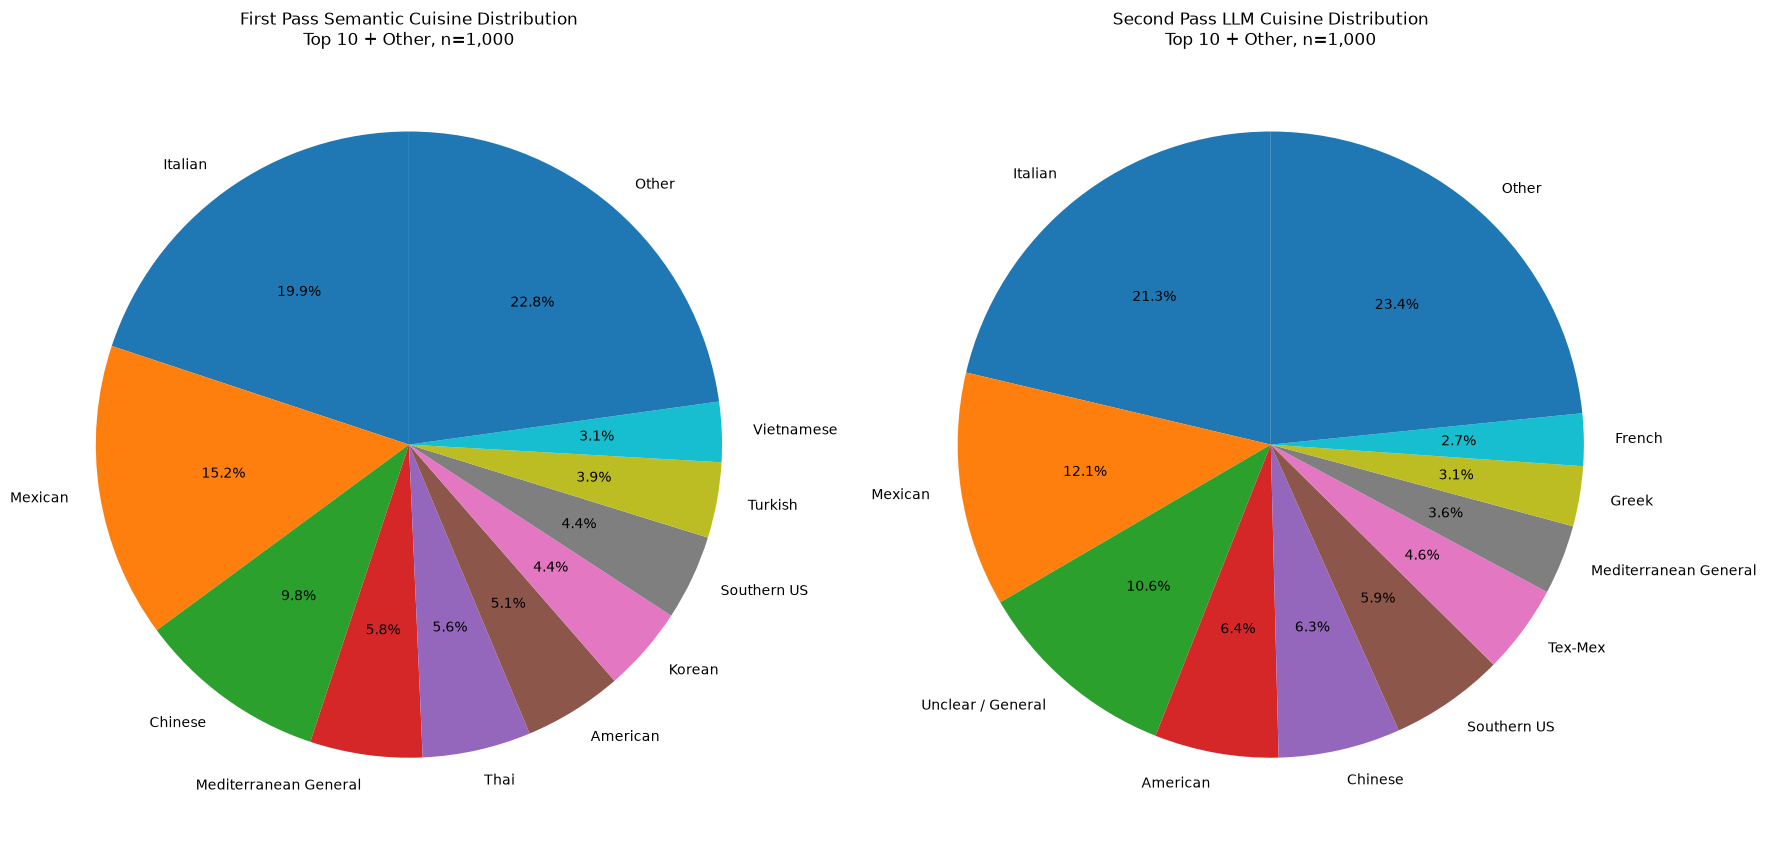

In [30]:
TOP_N = 10

def top_n_plus_other_counts(series, top_n=10):
    counts = (
        series
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .reset_index()
    )
    counts.columns = ["cuisine", "n_recipes"]

    top_counts = counts.head(top_n).copy()
    other_count = counts.iloc[top_n:]["n_recipes"].sum()

    if other_count > 0:
        top_counts = pd.concat(
            [
                top_counts,
                pd.DataFrame([{
                    "cuisine": "Other",
                    "n_recipes": other_count
                }])
            ],
            ignore_index=True
        )

    return top_counts


first_pass_pie = top_n_plus_other_counts(
    subset_comparison_df["semantic_cuisine"],
    top_n=TOP_N
)

second_pass_pie = top_n_plus_other_counts(
    subset_comparison_df["llm_cuisine"],
    top_n=TOP_N
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

axes[0].pie(
    first_pass_pie["n_recipes"],
    labels=first_pass_pie["cuisine"],
    autopct="%1.1f%%",
    startangle=90
)

axes[0].set_title(
    f"First Pass Semantic Cuisine Distribution\nTop {TOP_N} + Other, n={len(subset_comparison_df):,}"
)

axes[1].pie(
    second_pass_pie["n_recipes"],
    labels=second_pass_pie["cuisine"],
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title(
    f"Second Pass LLM Cuisine Distribution\nTop {TOP_N} + Other, n={len(subset_comparison_df):,}"
)

plt.tight_layout()
plt.show()

Save disagreement outputs and Pie

In [31]:
DISAGREEMENTS_OUT = OUT_DIR / "llm_subset_1000_exact_disagreements.csv"
FUSION_COMPONENT_AGREEMENTS_OUT = OUT_DIR / "llm_subset_1000_fusion_component_agreements.csv"
TRUE_DISAGREEMENTS_OUT = OUT_DIR / "llm_subset_1000_true_disagreements_after_fusion_adjustment.csv"
PIE_CHART_OUT = OUT_DIR / "llm_subset_1000_first_pass_vs_second_pass_pie.png"

exact_disagreements.to_csv(DISAGREEMENTS_OUT, index=False)
fusion_component_agreements.to_csv(FUSION_COMPONENT_AGREEMENTS_OUT, index=False)
true_disagreements.to_csv(TRUE_DISAGREEMENTS_OUT, index=False)

fig.savefig(PIE_CHART_OUT, dpi=300, bbox_inches="tight")

print("Wrote:", DISAGREEMENTS_OUT)
print("Wrote:", FUSION_COMPONENT_AGREEMENTS_OUT)
print("Wrote:", TRUE_DISAGREEMENTS_OUT)
print("Wrote:", PIE_CHART_OUT)

Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_subset_1000_exact_disagreements.csv
Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_subset_1000_fusion_component_agreements.csv
Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_subset_1000_true_disagreements_after_fusion_adjustment.csv
Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_subset_1000_first_pass_vs_second_pass_pie.png


Bar chart

,first_pass_semantic,second_pass_llm,combined_total
Italian,199,213,412
Mexican,152,121,273
Chinese,98,63,161
American,51,64,115
Unclear / General,0,106,106
Southern US,44,59,103
Mediterranean General,58,36,94
Thai,56,21,77
Greek,29,31,60
Tex-Mex,11,46,57


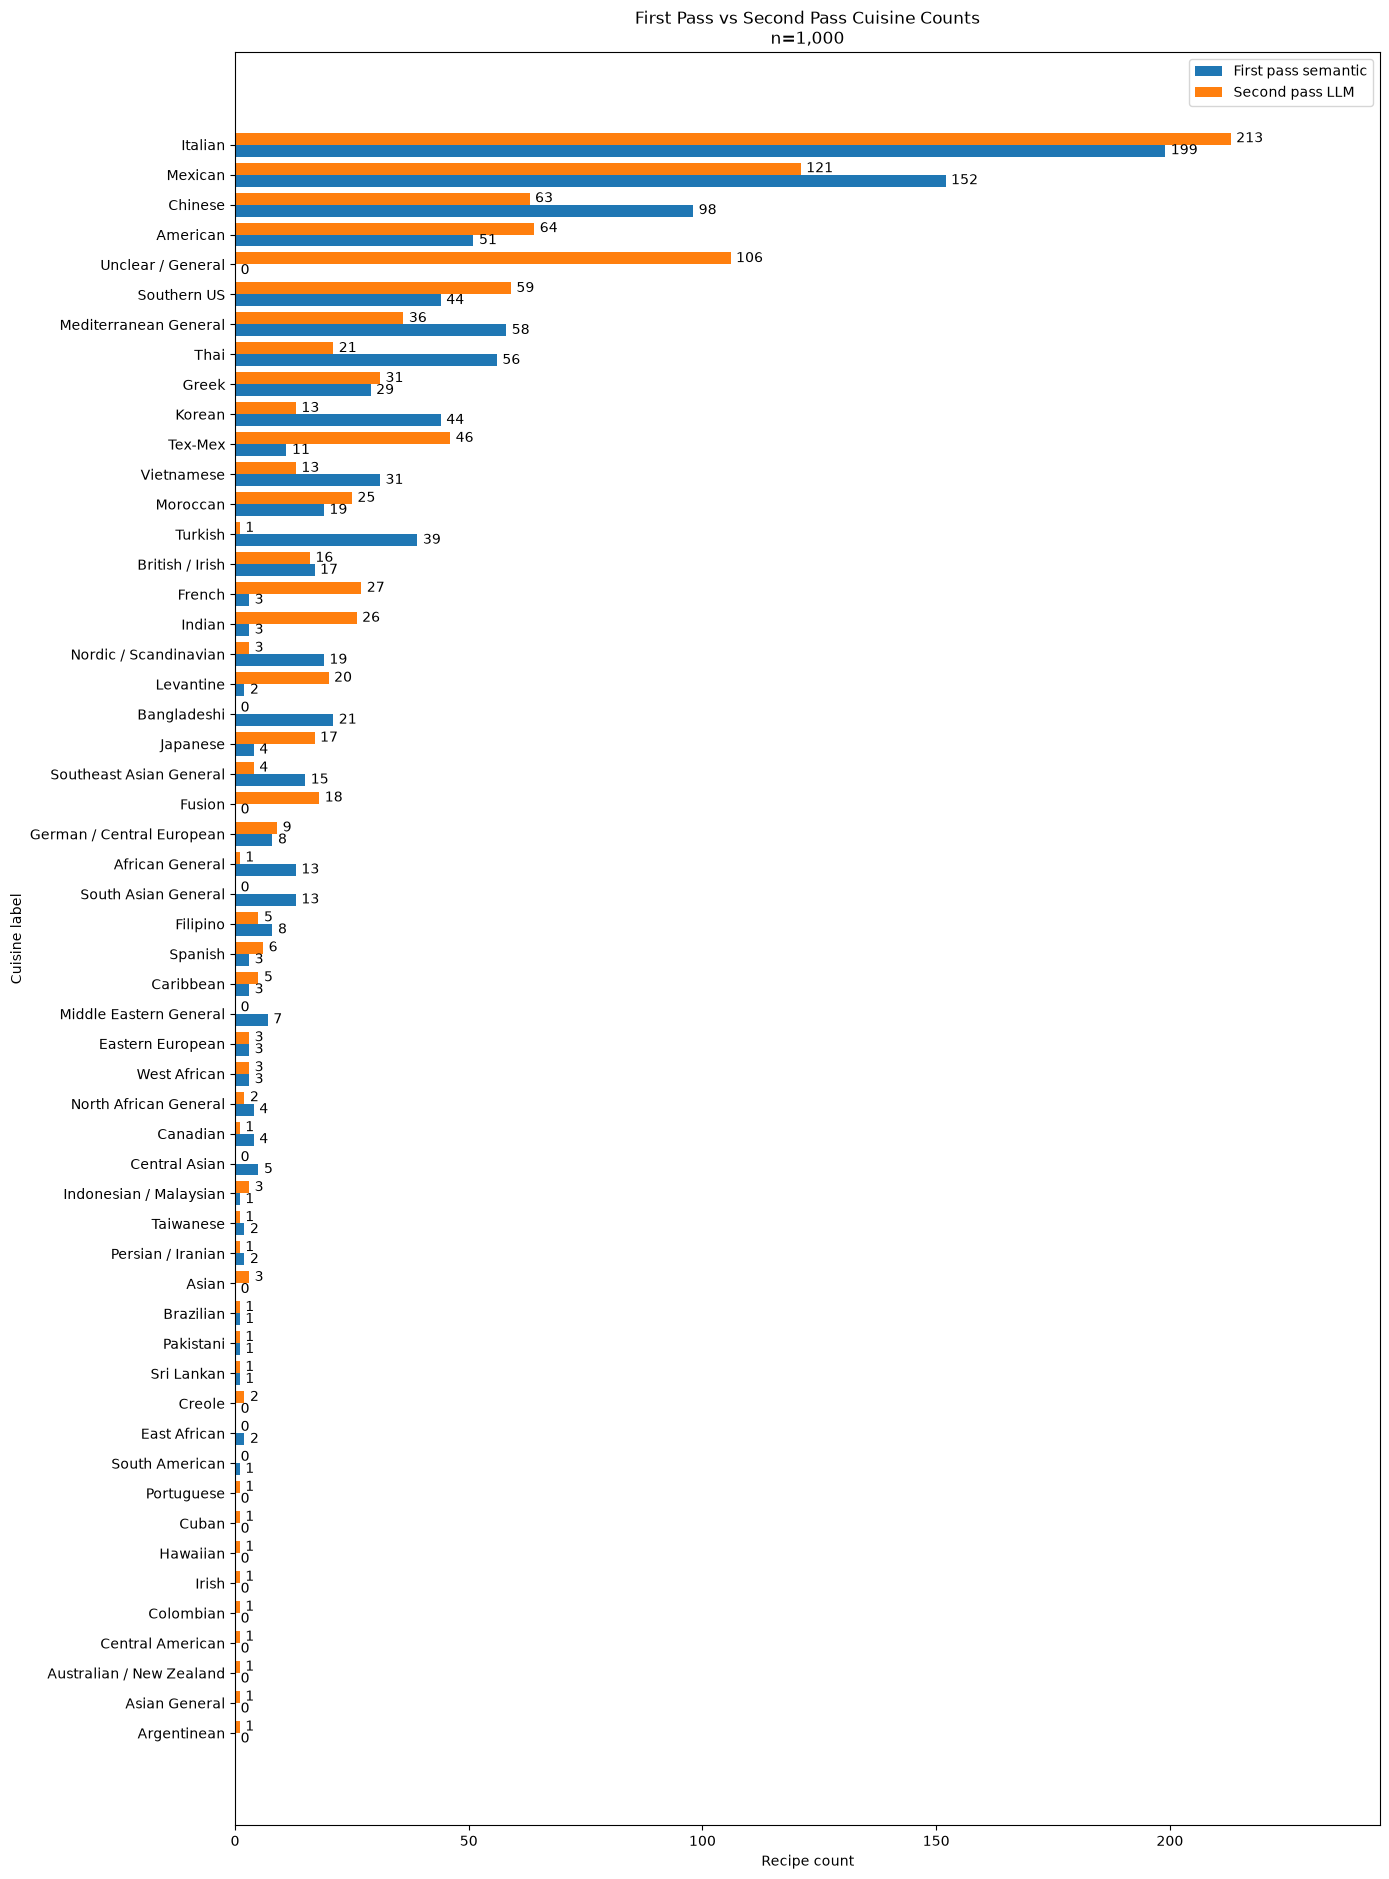

In [32]:
# Side-by-side bar chart: first pass vs second pass cuisine counts

bar_counts = pd.DataFrame({
    "first_pass_semantic": subset_comparison_df["semantic_cuisine"]
        .fillna("Missing")
        .astype(str)
        .value_counts(),
    "second_pass_llm": subset_comparison_df["llm_cuisine"]
        .fillna("Missing")
        .astype(str)
        .value_counts(),
}).fillna(0).astype(int)

bar_counts["combined_total"] = (
    bar_counts["first_pass_semantic"] + bar_counts["second_pass_llm"]
)

bar_counts = bar_counts.sort_values("combined_total", ascending=True)

display(bar_counts.sort_values("combined_total", ascending=False))

labels = bar_counts.index.tolist()
y = np.arange(len(labels))
bar_height = 0.4

fig_height = max(8, len(labels) * 0.35)
fig, ax = plt.subplots(figsize=(14, fig_height))

first_bars = ax.barh(
    y - bar_height / 2,
    bar_counts["first_pass_semantic"],
    height=bar_height,
    label="First pass semantic"
)

second_bars = ax.barh(
    y + bar_height / 2,
    bar_counts["second_pass_llm"],
    height=bar_height,
    label="Second pass LLM"
)

ax.set_yticks(y)
ax.set_yticklabels(labels)

ax.set_xlabel("Recipe count")
ax.set_ylabel("Cuisine label")
ax.set_title(
    f"First Pass vs Second Pass Cuisine Counts\nn={len(subset_comparison_df):,}"
)

ax.legend()

# Add count labels to each bar
ax.bar_label(first_bars, labels=[f"{v:,}" for v in bar_counts["first_pass_semantic"]], padding=4)
ax.bar_label(second_bars, labels=[f"{v:,}" for v in bar_counts["second_pass_llm"]], padding=4)

# Add room on the right for labels
max_count = bar_counts[["first_pass_semantic", "second_pass_llm"]].to_numpy().max()
ax.set_xlim(0, max_count * 1.15 if max_count > 0 else 1)

plt.tight_layout()
plt.show()

save bar

In [33]:
BAR_CHART_OUT = OUT_DIR / "llm_subset_1000_first_pass_vs_second_pass_bar_counts.png"

fig.savefig(BAR_CHART_OUT, dpi=300, bbox_inches="tight")

print("Wrote:", BAR_CHART_OUT)

Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_subset_1000_first_pass_vs_second_pass_bar_counts.png


Save 1000

In [23]:
SUBSET_COMPARISON_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_subset_1000_comparison.parquet"
SUBSET_COMPARISON_CSV_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_subset_1000_comparison.csv"

SUBSET_SUMMARY_OUT = OUT_DIR / "llm_second_pass_subset_1000_summary.csv"
SUBSET_BY_SEMANTIC_OUT = OUT_DIR / "llm_second_pass_subset_1000_by_semantic_cuisine.csv"
SUBSET_BY_LLM_OUT = OUT_DIR / "llm_second_pass_subset_1000_by_llm_cuisine.csv"

subset_comparison_df.to_parquet(SUBSET_COMPARISON_OUT, index=False)
subset_comparison_df.to_csv(SUBSET_COMPARISON_CSV_OUT, index=False)

subset_summary.to_csv(SUBSET_SUMMARY_OUT, index=False)
subset_by_semantic_cuisine.to_csv(SUBSET_BY_SEMANTIC_OUT, index=False)
subset_by_llm_cuisine.to_csv(SUBSET_BY_LLM_OUT, index=False)

print("Wrote:", SUBSET_COMPARISON_OUT)
print("Wrote:", SUBSET_COMPARISON_CSV_OUT)
print("Wrote:", SUBSET_SUMMARY_OUT)
print("Wrote:", SUBSET_BY_SEMANTIC_OUT)
print("Wrote:", SUBSET_BY_LLM_OUT)

Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_blind_high_confidence_subset_1000_comparison.parquet
Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_blind_high_confidence_subset_1000_comparison.csv
Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_subset_1000_summary.csv
Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_subset_1000_by_semantic_cuisine.csv
Wrote: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_subset_1000_by_llm_cuisine.csv


prep for full LLM pass

In [17]:
# Prepare full LLM second-pass run
# Run this immediately before the full LLM loop.

from pathlib import Path
import time
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Rebuild paths if needed
# ------------------------------------------------------------

if "ROOT" not in globals():
    # Notebook is in scratch/EDA, so go two levels up to Capstone repo root.
    ROOT = Path.cwd().parents[1]

if "OUT_DIR" not in globals():
    OUT_DIR = ROOT / "scratch" / "EDA" / "semantic_cuisine_labeling"
    OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Output dir:", OUT_DIR)

# ------------------------------------------------------------
# 2. Make sure the LLM tagging function exists
# ------------------------------------------------------------

required_names = [
    "MODEL_NAME",
    "tag_recipe_blind_with_llm",
]

missing_names = [name for name in required_names if name not in globals()]

if missing_names:
    raise NameError(
        "Missing required setup variables/functions: "
        + ", ".join(missing_names)
        + "\nRerun the LM Studio connection cell and the prompt/parser/tagging function cells first."
    )

print("Using model:", MODEL_NAME)

# ------------------------------------------------------------
# 3. Load semantic first-pass output if needed
# ------------------------------------------------------------

if "llm_source_df" in globals() and llm_source_df is not None:
    llm_source_df = llm_source_df.copy()
elif "stats_df" in globals() and stats_df is not None:
    llm_source_df = stats_df.copy()
elif "full_labeled" in globals() and full_labeled is not None:
    llm_source_df = full_labeled.copy()
else:
    FULL_OUT_PATH = OUT_DIR / "recipes_trimmed_semantic_cuisine_labeled_no_cookbooks.parquet"
    
    if not FULL_OUT_PATH.exists():
        raise FileNotFoundError(
            f"Could not find semantic first-pass output at: {FULL_OUT_PATH}"
        )
    
    llm_source_df = pd.read_parquet(FULL_OUT_PATH)

llm_source_df["recipe_id"] = llm_source_df["recipe_id"].astype(str)

print("Total semantic first-pass rows:", len(llm_source_df))

# ------------------------------------------------------------
# 4. Filter to only high-confidence semantic first-pass recipes
# ------------------------------------------------------------

if "semantic_cuisine_confidence" not in llm_source_df.columns:
    raise KeyError("Column missing: semantic_cuisine_confidence")

llm_input_df = llm_source_df.loc[
    llm_source_df["semantic_cuisine_confidence"] == "high"
].copy()

llm_input_df["recipe_id"] = llm_input_df["recipe_id"].astype(str)

print("High-confidence rows selected for full LLM second pass:", len(llm_input_df))

# ------------------------------------------------------------
# 5. Make sure there is usable recipe text
# ------------------------------------------------------------

if "semantic_text" not in llm_input_df.columns:
    print("semantic_text column not found. Creating fallback semantic_text from title/ingredients/NER.")
    
    title_col = "title" if "title" in llm_input_df.columns else None
    ingredients_col = "ingredients" if "ingredients" in llm_input_df.columns else None
    ner_col = "NER" if "NER" in llm_input_df.columns else ("ner" if "ner" in llm_input_df.columns else None)

    def make_fallback_semantic_text(row):
        parts = []
        if title_col:
            parts.append(f"Title: {row.get(title_col, '')}")
        if ingredients_col:
            parts.append(f"Ingredients: {row.get(ingredients_col, '')}")
        if ner_col:
            parts.append(f"Parsed ingredients: {row.get(ner_col, '')}")
        return " | ".join(str(x) for x in parts if str(x).strip())

    llm_input_df["semantic_text"] = llm_input_df.apply(make_fallback_semantic_text, axis=1)

# Basic sanity check
empty_text_count = (
    llm_input_df["semantic_text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Rows with empty semantic_text:", empty_text_count)

if empty_text_count == len(llm_input_df):
    raise ValueError("All selected rows have empty semantic_text. Check title/ingredients columns.")

# ------------------------------------------------------------
# 6. Set full-run checkpoint path
# ------------------------------------------------------------

LLM_SECOND_PASS_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_cuisine_labels_checkpoint.csv"

print("Checkpoint path:", LLM_SECOND_PASS_OUT)

# ------------------------------------------------------------
# 7. Resume checkpoint if it exists
# ------------------------------------------------------------

if LLM_SECOND_PASS_OUT.exists():
    completed_df = pd.read_csv(LLM_SECOND_PASS_OUT)
    completed_df["recipe_id"] = completed_df["recipe_id"].astype(str)

    # Drop accidental duplicate recipe IDs, keeping the latest saved row
    completed_df = completed_df.drop_duplicates(subset=["recipe_id"], keep="last")

    completed_ids = set(completed_df["recipe_id"])
    llm_results = completed_df.to_dict("records")

    print(f"Loaded checkpoint with {len(completed_ids):,} completed recipes.")
else:
    completed_ids = set()
    llm_results = []

    print("No checkpoint found. Starting fresh.")

# ------------------------------------------------------------
# 8. Create rows_to_tag for the full loop
# ------------------------------------------------------------

rows_to_tag = llm_input_df.loc[
    ~llm_input_df["recipe_id"].isin(completed_ids)
].copy()

print("Full high-confidence input rows:", len(llm_input_df))
print("Completed rows:", len(completed_ids))
print("Rows remaining:", len(rows_to_tag))

# ------------------------------------------------------------
# 9. Preview rows that will be sent to the LLM
# ------------------------------------------------------------

preview_cols = [
    col for col in [
        "recipe_id",
        "title",
        "semantic_text",
        "semantic_cuisine",
        "semantic_cuisine_score",
        "semantic_cuisine_margin",
        "semantic_cuisine_confidence",
    ]
    if col in rows_to_tag.columns
]

display(rows_to_tag[preview_cols].head(10))

print("Ready to run the full LLM second-pass loop.")

Project root: c:\Users\winni\Documents\GitHub\Capstone\Capstone
Output dir: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling
Using model: qwen/qwen3.6-35b-a3b
Total semantic first-pass rows: 1229020
High-confidence rows selected for full LLM second pass: 84345
Rows with empty semantic_text: 0
Checkpoint path: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_blind_high_confidence_cuisine_labels_checkpoint.csv
No checkpoint found. Starting fresh.
Full high-confidence input rows: 84345
Completed rows: 0
Rows remaining: 84345


,recipe_id,title,semantic_text,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence
6,896347,Navajo Tacos,Title: Navajo Tacos | Ingredient names: Chili Beans pinto beans water frozen chili ground cumin oregano garlic onion powder salt Fry Bread flour baking powder salt hot water lard Toppings Cheddar cheese tomatoes onions,Mexican,0.581307,0.061942,high
21,896362,Dawn Fried Rice,Title: Dawn Fried Rice | Ingredient names: water white rice ground beef soy sauce teriyaki sauce curry powder mushrooms carrots ground cumin,South Asian General,0.558453,0.056688,high
45,896390,Feta And Slow-Roasted Tomato Salad With French Green Beans,Title: Feta And Slow-Roasted Tomato Salad With French Green Beans | Ingredient names: tomatoes salt olive oil bay leaf pine nuts green beans arugula fresh basil red wine vinegar whole-grain mustard garlic honey olive oil feta cheese,Mediterranean General,0.604343,0.068394,high
47,896392,Italian Zucchini Soup,Title: Italian Zucchini Soup | Ingredient names: zucchini tomatoes green bell pepper celery onion tomato soup white sugar salt black pepper,Italian,0.578753,0.102753,high
65,896411,"Chia Seed, Coconut, And Raspberry French Toast Sticks","Title: Chia Seed, Coconut, And Raspberry French Toast Sticks | Ingredient names: grain bread coconut chia seeds eggs white sugar ground cinnamon vanilla salt unsalted butter fresh raspberries vanilla yogurt maple syrup",West African,0.553079,0.065943,high
71,896417,Italian Tomato Pasta Salad,Title: Italian Tomato Pasta Salad | Ingredient names: pasta Italian dressing tomatoes Parmesan cheese,Italian,0.679675,0.133960,high
154,896513,Kikkoman Chinese Pepper Steak,Title: Kikkoman Chinese Pepper Steak | Ingredient names: beef sirloin Hoisin Sauce vegetable oil bell peppers onions Hoisin Sauce,Chinese,0.594691,0.096053,high
168,896528,The Sriracha Chicken Marinade,Title: The Sriracha Chicken Marinade | Ingredient names: sriracha sauce apple cider vinegar maple syrup ghost pepper,Thai,0.552711,0.056936,high
186,896546,Tomato Alfredo Sauce With Artichokes,Title: Tomato Alfredo Sauce With Artichokes | Ingredient names: water tomatoes onion mushrooms fresh basil milk flour,Italian,0.569310,0.065490,high
195,896556,Spicy Roasted Tomato And Ricotta Pasta Sauce,Title: Spicy Roasted Tomato And Ricotta Pasta Sauce | Ingredient names: tomatoes olive oil garlic salt ground black pepper white sugar Italian seasoning rosemary basil parsley garlic onion powder red pepper ground hot Italian sausage sweet onion ...,Italian,0.664705,0.106804,high


Ready to run the full LLM second-pass loop.


full LLM second pass (high confidence)

In [10]:
# Full LLM second-pass loop — safer overnight version
# Run this after Cell 106 says it is ready.

import time
import pandas as pd

SAVE_EVERY = 10
SLEEP_SECONDS = 0.0

start_time = time.perf_counter()
new_results_this_run = 0

try:
    for i, (_, row) in enumerate(rows_to_tag.iterrows(), start=1):
        print(
            f"Tagging {i}/{len(rows_to_tag)} | "
            f"recipe_id={row['recipe_id']} | "
            f"title={row.get('title', '')}"
        )

        result = tag_recipe_blind_with_llm(
            row,
            model_name=MODEL_NAME,
            sleep_seconds=SLEEP_SECONDS,
        )

        llm_results.append(result)
        new_results_this_run += 1

        if i % SAVE_EVERY == 0:
            checkpoint_df = (
                pd.DataFrame(llm_results)
                .drop_duplicates(subset=["recipe_id"], keep="last")
            )

            checkpoint_df.to_csv(LLM_SECOND_PASS_OUT, index=False)

            elapsed = time.perf_counter() - start_time
            recipes_per_second = i / elapsed if elapsed > 0 else 0
            remaining = len(rows_to_tag) - i
            estimated_remaining_minutes = (
                remaining / recipes_per_second / 60
                if recipes_per_second > 0
                else None
            )

            print(f"\nCheckpoint saved: {LLM_SECOND_PASS_OUT}")
            print(f"Rows saved in checkpoint: {len(checkpoint_df):,}")
            print(f"New rows this run: {new_results_this_run:,}")
            print(f"Elapsed: {elapsed / 60:.1f} min")
            if estimated_remaining_minutes is not None:
                print(f"Estimated remaining: {estimated_remaining_minutes:.1f} min\n")

except KeyboardInterrupt:
    print("\nInterrupted manually. Saving progress before stopping...")

finally:
    llm_second_pass_df = (
        pd.DataFrame(llm_results)
        .drop_duplicates(subset=["recipe_id"], keep="last")
    )

    llm_second_pass_df.to_csv(LLM_SECOND_PASS_OUT, index=False)

    elapsed = time.perf_counter() - start_time

    print("\nProgress saved:", LLM_SECOND_PASS_OUT)
    print(f"Elapsed this run: {elapsed / 60:.1f} minutes")
    print("Rows saved in checkpoint:", len(llm_second_pass_df))
    print("New rows completed this run:", new_results_this_run)

    display(llm_second_pass_df.tail())


Progress saved: c:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\llm_second_pass_blind_high_confidence_cuisine_labels_checkpoint.csv
Elapsed this run: 0.0 minutes
Rows saved in checkpoint: 0
New rows completed this run: 0


""


NameError: name 'rows_to_tag' is not defined

Load final results

In [ ]:
llm_second_pass_df = pd.read_csv(LLM_SECOND_PASS_OUT)

llm_second_pass_df["recipe_id"] = llm_second_pass_df["recipe_id"].astype(str)

llm_second_pass_df["llm_certainty_score"] = pd.to_numeric(
    llm_second_pass_df["llm_certainty_score"],
    errors="coerce"
)

print("LLM second-pass rows:", len(llm_second_pass_df))

display(llm_second_pass_df.head())

Join back to semantic labels for comparison

In [ ]:
comparison_df = llm_input_df.merge(
    llm_second_pass_df,
    on="recipe_id",
    how="left",
)

comparison_df["semantic_llm_agree"] = (
    comparison_df["semantic_cuisine"].astype(str)
    == comparison_df["llm_cuisine"].astype(str)
)

comparison_df["llm_has_error"] = comparison_df["llm_error"].notna()
comparison_df["llm_has_validation_error"] = comparison_df["llm_validation_errors"].notna()

print("Comparison rows:", len(comparison_df))
print("Agreement rate:", comparison_df["semantic_llm_agree"].mean())

display(
    comparison_df[
        [
            "recipe_id",
            "title",
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "semantic_cuisine_confidence",
            "llm_parent_cuisine",
            "llm_cuisine",
            "llm_is_fusion",
            "llm_fusion_components",
            "llm_certainty_score",
            "semantic_llm_agree",
            "llm_reason",
            "llm_evidence",
            "llm_validation_errors",
            "llm_error",
        ]
    ].head(50)
)

summary of second pass

In [ ]:
llm_summary = (
    comparison_df
    .groupby(["llm_parent_cuisine", "llm_cuisine"], dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_llm_certainty=("llm_certainty_score", "mean"),
        median_llm_certainty=("llm_certainty_score", "median"),
        n_fusion=("llm_is_fusion", lambda s: (s == True).sum()),
        agreement_rate=("semantic_llm_agree", "mean"),
        validation_error_count=("llm_has_validation_error", "sum"),
        error_count=("llm_has_error", "sum"),
    )
    .reset_index()
    .sort_values("n_recipes", ascending=False)
)

display(llm_summary.head(50))

Agreement summary by semantic first-pass

In [ ]:
llm_summary = (
    comparison_df
    .groupby(["llm_parent_cuisine", "llm_cuisine"], dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_llm_certainty=("llm_certainty_score", "mean"),
        median_llm_certainty=("llm_certainty_score", "median"),
        n_fusion=("llm_is_fusion", lambda s: (s == True).sum()),
        agreement_rate=("semantic_llm_agree", "mean"),
        validation_error_count=("llm_has_validation_error", "sum"),
        error_count=("llm_has_error", "sum"),
    )
    .reset_index()
    .sort_values("n_recipes", ascending=False)
)

display(llm_summary.head(50))

save final comparison

In [ ]:
COMPARISON_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_comparison.parquet"
COMPARISON_CSV_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_comparison.csv"

LLM_SUMMARY_OUT = OUT_DIR / "llm_second_pass_blind_high_confidence_summary.csv"
AGREEMENT_SUMMARY_OUT = OUT_DIR / "llm_second_pass_agreement_by_semantic_cuisine.csv"

comparison_df.to_parquet(COMPARISON_OUT, index=False)
comparison_df.to_csv(COMPARISON_CSV_OUT, index=False)

llm_summary.to_csv(LLM_SUMMARY_OUT, index=False)
agreement_by_semantic_cuisine.to_csv(AGREEMENT_SUMMARY_OUT, index=False)

print("Wrote:", COMPARISON_OUT)
print("Wrote:", COMPARISON_CSV_OUT)
print("Wrote:", LLM_SUMMARY_OUT)
print("Wrote:", AGREEMENT_SUMMARY_OUT)

best final high confidence agreement set

In [ ]:
final_high_agreement_df = comparison_df.loc[
    (comparison_df["semantic_llm_agree"] == True)
    & (comparison_df["llm_certainty_score"] >= 0.75)
    & (comparison_df["llm_has_error"] == False)
    & (comparison_df["llm_has_validation_error"] == False)
].copy()

FINAL_HIGH_AGREEMENT_OUT = OUT_DIR / "final_high_confidence_semantic_llm_agreement_recipes.parquet"
FINAL_HIGH_AGREEMENT_CSV_OUT = OUT_DIR / "final_high_confidence_semantic_llm_agreement_recipes.csv"

final_high_agreement_df.to_parquet(FINAL_HIGH_AGREEMENT_OUT, index=False)
final_high_agreement_df.to_csv(FINAL_HIGH_AGREEMENT_CSV_OUT, index=False)

print("Final high-agreement rows:", len(final_high_agreement_df))
print("Wrote:", FINAL_HIGH_AGREEMENT_OUT)
print("Wrote:", FINAL_HIGH_AGREEMENT_CSV_OUT)

display(
    final_high_agreement_df[
        [
            "recipe_id",
            "title",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "llm_cuisine",
            "llm_certainty_score",
            "llm_reason",
            "llm_evidence",
        ]
    ].head(50)
)